<a href="https://colab.research.google.com/github/xyt556/Geo_Programe/blob/main/geospatial/geemap%E6%95%99%E6%A1%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Geemap 完整教案

## 课程概述

**课程名称**：基于 Geemap 的地理空间数据分析与可视化  
**课程时长**：16 学时（8 个章节，每章节 2 学时）  
**适用对象**：地理信息科学、遥感、环境科学相关专业学生及研究人员  
**先修知识**：Python 基础、GIS 基本概念

---

## 第一章：环境配置与基础入门

### 1.1 学习目标

- 安装并配置 Geemap 运行环境
- 理解 Google Earth Engine（GEE）的基本概念
- 创建第一个交互式地图

### 1.2 理论知识

**什么是 Geemap？**
- Geemap 是基于 Google Earth Engine Python API 的开源包
- 提供交互式地图可视化（基于 ipyleaflet/folium）
- 简化 GEE 数据处理流程

**GEE 核心概念：**
- Image（影像）：单张栅格数据
- ImageCollection（影像集合）：时间序列影像
- Feature（要素）：矢量数据
- FeatureCollection（要素集合）：矢量数据集

### 1.3 实践程序

In [ ]:
# ============================================
# 第一章：环境配置与基础地图创建
# ============================================

# 步骤1：安装必要的库（在终端或Jupyter中运行）
# pip install geemap
# pip install earthengine-api


In [2]:

# 步骤2：导入库并认证
import ee
import geemap

# 首次使用需要认证（会打开浏览器进行Google账号认证）
ee.Authenticate()

# 初始化 Earth Engine
try:
    ee.Initialize(project='ee-xyt556')  # 替换为你的项目ID
    print("✅ Earth Engine 初始化成功！")
except Exception as e:
    print(f"❌ 初始化失败：{e}")

# ============================================
# 1.1 创建基础交互式地图
# ============================================

# 创建默认地图
Map = geemap.Map()
Map


✅ Earth Engine 初始化成功！


Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [ ]:

# ============================================
# 1.2 设置地图中心和缩放级别
# ============================================

# 方式一：使用经纬度
Map1 = geemap.Map(center=[39.9042, 116.4074], zoom=10)  # 北京
Map1


Map(center=[39.9042, 116.4074], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topr…

In [ ]:

# ============================================
# 1.3 添加不同底图
# ============================================

Map2 = geemap.Map(center=[39.9042, 116.4074], zoom=8)

# 查看所有可用底图
print("可用底图列表（前10个）：")
basemaps = list(geemap.basemaps.keys())
for bm in basemaps[:10]:
    print(f"  - {bm}")

# 添加不同底图
Map2.add_basemap("SATELLITE")        # 卫星影像
Map2.add_basemap("TERRAIN")          # 地形图
Map2.add_basemap("OpenTopoMap")      # 地形图（OpenStreetMap风格）

# 添加图层控制器
Map2.add_layer_control()
Map2


可用底图列表（前10个）：
  - OpenStreetMap
  - Esri.WorldStreetMap
  - Esri.WorldImagery
  - Esri.WorldTopoMap
  - FWS NWI Wetlands
  - FWS NWI Wetlands Raster
  - NLCD 2021 CONUS Land Cover
  - NLCD 2019 CONUS Land Cover
  - NLCD 2016 CONUS Land Cover
  - NLCD 2013 CONUS Land Cover


Map(center=[39.9042, 116.4074], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topr…

In [ ]:
# ============================================
# 1.4 地图基本属性设置
# ============================================

import geemap

Map3 = geemap.Map(
    center=[35.8617, 104.1954],  # 中国中心
    zoom=4,
    height="600px",              # 地图高度
    data_ctrl=True,              # 数据控制
    toolbar_ctrl=True,           # 工具栏控制
    scale_ctrl=True,             # 比例尺控件
    fullscreen_ctrl=True         # 全屏控件
)

Map3

Map(center=[35.8617, 104.1954], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topr…

In [ ]:

# ============================================
# 1.5 显示地图信息
# ============================================

print("=" * 50)
print("Geemap 版本信息")
print("=" * 50)
print(f"geemap 版本: {geemap.__version__}")
print(f"earthengine-api 版本: {ee.__version__}")

# 获取当前地图中心和缩放
print(f"\n当前地图中心: {Map3.center}")
print(f"当前缩放级别: {Map3.zoom}")

Geemap 版本信息
geemap 版本: 0.37.2
earthengine-api 版本: 1.7.29

当前地图中心: [35.8617, 104.1954]
当前缩放级别: 4.0


---

## 第二章：影像数据加载与可视化

### 2.1 学习目标

- 掌握 GEE 影像数据的加载方法
- 学习影像可视化参数设置
- 理解波段组合与色彩映射

### 2.2 理论知识

**影像可视化参数：**
- `min/max`：拉伸范围
- `bands`：波段选择
- `palette`：色彩方案
- `gamma`：伽马校正

### 2.3 实践程序

In [ ]:
# ============================================
# 第二章：影像数据加载与可视化
# ============================================


In [ ]:
# 方案1：从集合中搜索正确影像（推荐）

import ee
import geemap

ee.Initialize(project='ee-xyt556')

Map = geemap.Map(center=[39.9042, 116.4074], zoom=8)

# ============================================
# 方法：从集合中筛选影像（正确做法）
# ============================================

# 定义北京范围
beijing = ee.Geometry.Point([116.4074, 39.9042])

# 从影像集合中筛选
collection = (ee.ImageCollection('LANDSAT/LC08/C02/T1_TOA')
              .filterBounds(beijing)
              .filterDate('2020-06-01', '2020-08-31')
              .filter(ee.Filter.lt('CLOUD_COVER', 20))
              .sort('CLOUD_COVER'))  # 按云量排序，取最清晰的

# 查看有多少景
print("符合条件的影像数量:", collection.size().getInfo())

# 查看第一景的信息
first = collection.first()
print("第一景影像ID:", first.get('system:index').getInfo())
print("云量:", first.get('CLOUD_COVER').getInfo())
print("日期:", first.date().format('YYYY-MM-dd').getInfo())

# 取第一景（云量最少）
landsat8 = collection.first()

# 真彩色显示
vis_true_color = {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 0.3,
    'gamma': 1.4
}
Map.addLayer(landsat8, vis_true_color, '真彩色(Landsat8)')

# 假彩色显示（近红外合成）
vis_false_color = {
    'bands': ['B5', 'B4', 'B3'],
    'min': 0,
    'max': 0.5,
    'gamma': 1.4
}
Map.addLayer(landsat8, vis_false_color, '假彩色(NIR合成)')

Map.add_layer_control()
Map

符合条件的影像数量: 1
第一景影像ID: LC08_123032_20200803
云量: 4.08
日期: 2020-08-03


Map(center=[39.9042, 116.4074], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topr…

In [ ]:
# 方案2：先查询正确的影像ID再使用
import ee
import geemap

ee.Initialize(project='ee-xyt556')

# ============================================
# 先查询正确的影像ID
# ============================================

beijing = ee.Geometry.Point([116.4074, 39.9042])

collection = (ee.ImageCollection('LANDSAT/LC08/C02/T1_TOA')
              .filterBounds(beijing)
              .filterDate('2020-01-01', '2020-12-31')
              .filter(ee.Filter.lt('CLOUD_COVER', 30)))

# 获取所有影像的ID列表
id_list = collection.aggregate_array('system:index').getInfo()
date_list = collection.aggregate_array('DATE_ACQUIRED').getInfo()
cloud_list = collection.aggregate_array('CLOUD_COVER').getInfo()

print("=" * 60)
print("北京2020年可用Landsat 8影像列表：")
print("=" * 60)
print(f"{'影像ID':<35} {'日期':<15} {'云量':>8}")
print("-" * 60)

for img_id, date, cloud in zip(id_list, date_list, cloud_list):
    print(f"{img_id:<35} {date:<15} {cloud:>7.1f}%")

print(f"\n共找到 {len(id_list)} 景影像")

北京2020年可用Landsat 8影像列表：
影像ID                                日期                    云量
------------------------------------------------------------
LC08_123032_20200108                2020-01-08          5.5%
LC08_123032_20200124                2020-01-24          9.6%
LC08_123032_20200209                2020-02-09         17.4%
LC08_123032_20200312                2020-03-12         18.9%
LC08_123032_20200328                2020-03-28          2.4%
LC08_123032_20200413                2020-04-13          0.1%
LC08_123032_20200429                2020-04-29          2.7%
LC08_123032_20200803                2020-08-03          4.1%
LC08_123032_20200920                2020-09-20          0.2%
LC08_123032_20201006                2020-10-06          0.2%
LC08_123032_20201022                2020-10-22          0.0%
LC08_123032_20201123                2020-11-23         10.6%
LC08_123032_20201225                2020-12-25          1.7%
LO08_123032_20201107                2020-11-07          1.6%


In [ ]:
# 用查询到的真实ID加载（注意路径格式）
landsat8 = ee.Image('LANDSAT/LC08/C02/T1_TOA/LC08_123032_20200312')

In [ ]:
# 方案3：使用影像集合合成（最稳定的方式）
import ee
import geemap

ee.Initialize(project='ee-xyt556')

Map = geemap.Map(center=[39.9042, 116.4074], zoom=8)

# ============================================
# 用影像集合合成（无需关心单景ID）
# ============================================

beijing_roi = ee.Geometry.Rectangle([115.7, 39.4, 117.4, 41.1])

# 2020年夏季合成（中值合成自动去云）
landsat8_composite = (ee.ImageCollection('LANDSAT/LC08/C02/T1_TOA')
                      .filterBounds(beijing_roi)
                      .filterDate('2020-06-01', '2020-09-30')
                      .filter(ee.Filter.lt('CLOUD_COVER', 30))
                      .median()               # 中值合成去云
                      .clip(beijing_roi))

print("影像集合合成完成！")

# 真彩色显示
vis_true_color = {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 0.3,
    'gamma': 1.4
}
Map.addLayer(landsat8_composite, vis_true_color, '真彩色(2020夏季合成)')

# 假彩色显示
vis_false_color = {
    'bands': ['B5', 'B4', 'B3'],
    'min': 0,
    'max': 0.5,
    'gamma': 1.4
}
Map.addLayer(landsat8_composite, vis_false_color, '假彩色(NIR合成)')

# 短波红外合成（城市分析常用）
vis_swir = {
    'bands': ['B6', 'B5', 'B4'],
    'min': 0,
    'max': 0.5,
    'gamma': 1.3
}
Map.addLayer(landsat8_composite, vis_swir, '短波红外合成')

Map.add_layer_control()
Map

影像集合合成完成！


Map(center=[39.9042, 116.4074], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topr…

In [ ]:

# ============================================
# 2.2 加载 Sentinel-2 数据
# ============================================

Map2 = geemap.Map(center=[30.5728, 104.0668], zoom=9)  # 成都

# 加载 Sentinel-2 影像集合
sentinel2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
             .filterDate('2023-06-01', '2023-08-31')
             .filterBounds(ee.Geometry.Point([104.0668, 30.5728]))
             .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
             .first())

# Sentinel-2 真彩色
s2_vis = {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 3000,
    'gamma': 1.3
}
Map2.addLayer(sentinel2, s2_vis, 'Sentinel-2 真彩色')

# Sentinel-2 假彩色（植被）
s2_veg = {
    'bands': ['B8', 'B4', 'B3'],
    'min': 0,
    'max': 4000
}
Map2.addLayer(sentinel2, s2_veg, 'Sentinel-2 植被假彩色')

Map2.add_layer_control()
Map2


Map(center=[30.5728, 104.0668], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topr…

In [ ]:

# ============================================
# 2.3 单波段可视化与调色板
# ============================================

Map3 = geemap.Map(center=[35.8617, 104.1954], zoom=4)

# 加载 SRTM 数字高程模型
dem = ee.Image('USGS/SRTMGL1_003')

# 使用调色板显示高程
dem_vis = {
    'min': 0,
    'max': 5000,
    'palette': ['006633', 'E5FFCC', '662A00', 'D8D8D8', 'F5F5F5']
}
Map3.addLayer(dem, dem_vis, 'SRTM高程(自定义调色板)')

# 使用 geemap 内置调色板
palette_terrain = cm.get_palette('terrain', n_class=10)
print("地形调色板:", palette_terrain)

dem_vis2 = {
    'min': 0,
    'max': 5000,
    'palette': palette_terrain
}
Map3.addLayer(dem, dem_vis2, 'SRTM高程(地形调色板)')


地形调色板: ['333399', '0e7ee4', '00bc94', '55dd77', 'c5f38d', 'e2da89', 'aa926b', '8f7069', 'c7b7b4', 'ffffff']


In [ ]:

# 添加颜色条图例
Map3.add_colorbar(
    vis_params=dem_vis2,
    label="海拔高度 (m)",
    orientation="horizontal",
    position="bottomleft"
)

Map3.add_layer_control()
Map3


Map(center=[35.8617, 104.1954], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topr…

In [ ]:

# ============================================
# 2.4 影像波段信息查看
# ============================================

print("=" * 50)
print("Landsat 8 波段信息")
print("=" * 50)

# 获取波段名称
band_names = landsat8.bandNames().getInfo()
print(f"波段数量: {len(band_names)}")
print(f"波段名称: {band_names}")

# 获取影像属性
info = landsat8.getInfo()
print(f"\n影像ID: {info['id']}")
print(f"投影: {landsat8.select('B1').projection().crs().getInfo()}")

# 获取统计信息
stats = landsat8.select('B4').reduceRegion(
    reducer=ee.Reducer.minMax(),
    scale=30,
    maxPixels=1e9,
    bestEffort=True
).getInfo()
print(f"\nB4波段范围: {stats}")


Landsat 8 波段信息
波段数量: 17
波段名称: ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9', 'B10', 'B11', 'QA_PIXEL', 'QA_RADSAT', 'SAA', 'SZA', 'VAA', 'VZA']

影像ID: LANDSAT/LC08/C02/T1_TOA/LC08_123032_20200312
投影: EPSG:32650

B4波段范围: {'B4_max': 1.8126121759414673, 'B4_min': 0.019522972404956818}


In [ ]:

# ============================================
# 2.5 多种内置调色板展示
# ============================================

# 查看所有可用调色板
print("\n常用调色板列表：")
palettes_list = ['viridis', 'plasma', 'inferno', 'magma',
                 'terrain', 'RdYlGn', 'Blues', 'Reds']
for p in palettes_list:
    palette = cm.get_palette(p, n_class=8)
    print(f"  {p}: {palette[:3]}...")


常用调色板列表：
  viridis: ['440154', '46327e', '365c8d']...
  plasma: ['0d0887', '5302a3', '8b0aa5']...
  inferno: ['000004', '280b53', '65156e']...
  magma: ['000004', '221150', '5f187f']...
  terrain: ['333399', '0393f9', '25d36d']...
  RdYlGn: ['a50026', 'e34933', 'fca55d']...
  Blues: ['f7fbff', 'dbe9f6', 'bad6eb']...
  Reds: ['fff5f0', 'fedbcc', 'fcaf93']...


---

## 第三章：影像集合处理与时间序列分析

### 3.1 学习目标

- 掌握 ImageCollection 的过滤与处理
- 学习影像合成（中值、均值等）
- 实现基本的时间序列分析

### 3.2 实践程序

In [ ]:
# ============================================
# 第三章：影像集合处理与时间序列分析
# ============================================

import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']  # 支持中文
matplotlib.rcParams['axes.unicode_minus'] = False

ee.Initialize(project='ee-xyt556')


In [ ]:

# ============================================
# 3.1 影像集合基本操作
# ============================================

# 定义研究区域（北京）
beijing = ee.Geometry.Rectangle([115.7, 39.4, 117.4, 41.1])

# 加载并过滤 Landsat 8 影像集合
collection = (ee.ImageCollection('LANDSAT/LC08/C02/T1_TOA')
              .filterDate('2020-01-01', '2020-12-31')
              .filterBounds(beijing)
              .filter(ee.Filter.lt('CLOUD_COVER', 30)))

# 查看影像数量
count = collection.size().getInfo()
print(f"符合条件的影像数量: {count}")

# 查看影像日期
dates = collection.aggregate_array('DATE_ACQUIRED').getInfo()
print(f"影像日期列表:")
for d in sorted(dates):
    print(f"  {d}")


符合条件的影像数量: 120
影像日期列表:
  2020-01-01
  2020-01-01
  2020-01-01
  2020-01-08
  2020-01-08
  2020-01-08
  2020-01-15
  2020-01-15
  2020-01-15
  2020-01-17
  2020-01-17
  2020-01-17
  2020-01-24
  2020-01-24
  2020-01-24
  2020-01-31
  2020-01-31
  2020-01-31
  2020-02-09
  2020-02-09
  2020-02-16
  2020-02-16
  2020-02-18
  2020-02-18
  2020-03-03
  2020-03-03
  2020-03-05
  2020-03-05
  2020-03-05
  2020-03-12
  2020-03-12
  2020-03-19
  2020-03-19
  2020-03-19
  2020-03-21
  2020-03-28
  2020-03-28
  2020-03-28
  2020-04-04
  2020-04-04
  2020-04-04
  2020-04-06
  2020-04-06
  2020-04-06
  2020-04-13
  2020-04-13
  2020-04-13
  2020-04-20
  2020-04-20
  2020-04-22
  2020-04-22
  2020-04-22
  2020-04-29
  2020-04-29
  2020-04-29
  2020-05-06
  2020-05-06
  2020-05-06
  2020-05-22
  2020-05-22
  2020-05-24
  2020-05-24
  2020-05-24
  2020-05-31
  2020-06-07
  2020-06-16
  2020-06-23
  2020-08-03
  2020-08-10
  2020-08-10
  2020-08-10
  2020-08-26
  2020-08-26
  2020-08-28
  2020-08-28
  

In [ ]:

# ============================================
# 3.2 影像合成方法比较
# ============================================

Map = geemap.Map(center=[40.0, 116.5], zoom=8)
Map.addLayer(beijing, {}, '研究区域', opacity=0.3)

vis_params = {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 0.35,
    'gamma': 1.4
}

# 中值合成（去云效果好）
median_composite = collection.median()
Map.addLayer(median_composite, vis_params, '中值合成')

# 均值合成
mean_composite = collection.mean()
Map.addLayer(mean_composite, vis_params, '均值合成')

# 最小值合成（适合植被分析）
min_composite = collection.min()
Map.addLayer(min_composite, vis_params, '最小值合成')

# 最大NDVI合成（保留植被信息最好）
def add_ndvi(image):
    ndvi = image.normalizedDifference(['B5', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

collection_ndvi = collection.map(add_ndvi)
max_ndvi_composite = collection_ndvi.qualityMosaic('NDVI')
Map.addLayer(max_ndvi_composite, vis_params, '最大NDVI合成')

Map.add_layer_control()
Map


Map(center=[40.0, 116.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [ ]:

# ============================================
# 3.3 季节性合成分析
# ============================================

Map2 = geemap.Map(center=[40.0, 116.5], zoom=7)

def get_seasonal_composite(year, start_month, end_month, season_name):
    """获取季节性合成影像"""
    start = f'{year}-{start_month:02d}-01'
    end = f'{year}-{end_month:02d}-28'

    composite = (ee.ImageCollection('LANDSAT/LC08/C02/T1_TOA')
                 .filterDate(start, end)
                 .filterBounds(beijing)
                 .filter(ee.Filter.lt('CLOUD_COVER', 30))
                 .median())
    return composite

# 四季合成
spring = get_seasonal_composite(2020, 3, 5, '春季')
summer = get_seasonal_composite(2020, 6, 8, '夏季')
autumn = get_seasonal_composite(2020, 9, 11, '秋季')
winter = get_seasonal_composite(2020, 12, 12, '冬季')

vis = {'bands': ['B5', 'B4', 'B3'], 'min': 0, 'max': 0.5, 'gamma': 1.3}
Map2.addLayer(spring, vis, '春季(3-5月)')
Map2.addLayer(summer, vis, '夏季(6-8月)')
Map2.addLayer(autumn, vis, '秋季(9-11月)')
Map2.addLayer(winter, vis, '冬季(12月)')
Map2.add_layer_control()
Map2


Map(center=[40.0, 116.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

时间序列数据点数: 43
        date      NDVI
0 2020-01-08  0.093072
1 2020-01-24  0.063420
2 2020-02-09  0.071317
3 2020-03-12  0.052536
4 2020-03-28  0.110495
5 2020-04-13  0.145093
6 2020-04-29  0.173775
7 2020-08-03  0.183284
8 2020-09-20  0.200940
9 2020-10-06  0.172569


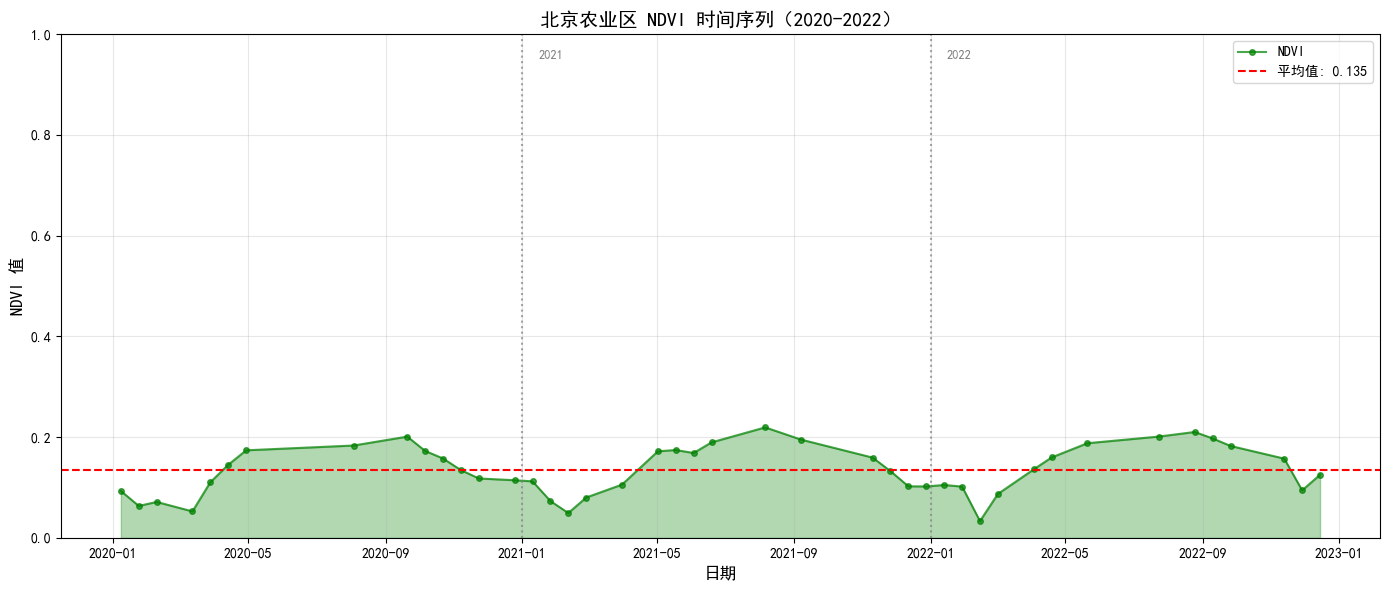

✅ 时间序列图已保存


In [ ]:

# ============================================
# 3.4 时间序列 NDVI 分析
# ============================================

# 定义样本点（北京某农业区）
sample_point = ee.Geometry.Point([116.5, 39.8])

# 计算NDVI时间序列
def compute_ndvi_ts(image):
    ndvi = image.normalizedDifference(['B5', 'B4']).rename('NDVI')
    date = image.date().format('YYYY-MM-dd')

    # 提取点位NDVI值
    value = ndvi.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=sample_point,
        scale=30
    )
    return image.set('date', date).set('NDVI', value.get('NDVI'))

# 2020-2022年NDVI时间序列
ts_collection = (ee.ImageCollection('LANDSAT/LC08/C02/T1_TOA')
                 .filterDate('2020-01-01', '2022-12-31')
                 .filterBounds(sample_point)
                 .filter(ee.Filter.lt('CLOUD_COVER', 20))
                 .map(compute_ndvi_ts))

# 提取时间序列数据
ts_data = ts_collection.reduceColumns(
    ee.Reducer.toList(2),
    ['date', 'NDVI']
).get('list').getInfo()

# 转换为DataFrame
df = pd.DataFrame(ts_data, columns=['date', 'NDVI'])
df['date'] = pd.to_datetime(df['date'])
df = df.dropna().sort_values('date')
df = df[df['NDVI'] > 0]  # 过滤无效值

print(f"时间序列数据点数: {len(df)}")
print(df.head(10))

# 绘制时间序列图
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df['date'], df['NDVI'], 'go-', linewidth=1.5,
        markersize=4, alpha=0.7, label='NDVI')
ax.axhline(y=df['NDVI'].mean(), color='r', linestyle='--',
           label=f'平均值: {df["NDVI"].mean():.3f}')
ax.fill_between(df['date'], df['NDVI'], alpha=0.3, color='green')
ax.set_xlabel('日期', fontsize=12)
ax.set_ylabel('NDVI 值', fontsize=12)
ax.set_title('北京农业区 NDVI 时间序列（2020-2022）', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

# 添加年份分割线
for year in [2021, 2022]:
    ax.axvline(x=pd.Timestamp(f'{year}-01-01'),
               color='gray', linestyle=':', alpha=0.7)
    ax.text(pd.Timestamp(f'{year}-01-15'), 0.95,
            str(year), fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('ndvi_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 时间序列图已保存")

---

## 第四章：植被与土地利用分析

### 4.1 学习目标

- 计算多种植被指数
- 加载并分析土地利用数据
- 统计各类别面积

### 4.2 实践程序

In [ ]:
# ============================================
# 第四章：植被与土地利用分析
# ============================================

import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

ee.Initialize(project='ee-xyt556')

# 定义研究区域（江苏省）
jiangsu = ee.FeatureCollection('FAO/GAUL/2015/level1') \
           .filter(ee.Filter.eq('ADM1_NAME', 'Jiangsu Sheng'))
jiangsu

In [ ]:
# 获取中国省级行政区名称
import ee
import pandas as pd

# 初始化
ee.Initialize(project='ee-xyt556')

# 1. 读取 GAUL level1 数据
dataset = ee.FeatureCollection('FAO/GAUL/2015/level1')

# 2. 筛选中国
china_provinces = dataset.filter(ee.Filter.eq('ADM0_NAME', 'China'))

# 3. 查看字段名
print("字段名：")
print(china_provinces.first().propertyNames().getInfo())

# 4. 获取省级名称
province_names = sorted(set(china_provinces.aggregate_array('ADM1_NAME').getInfo()))

print("\n中国省级行政区名称（英文）:")
for i, name in enumerate(province_names, 1):
    print(f"{i:02d}. {name}")

print(f"\n共 {len(province_names)} 个一级行政区。")

# 5. 英文名 -> 中文名 对照表
# 注意：不同数据集的英文写法可能略有差异
# 所以这里尽量写得兼容一些，如果个别对不上，请按你打印出的英文名微调
name_map = {
    'Anhui': '安徽',
    'Beijing': '北京',
    'Chongqing': '重庆',
    'Fujian': '福建',
    'Gansu': '甘肃',
    'Guangdong': '广东',
    'Guangxi': '广西',
    'Guangxi Zhuang': '广西',
    'Guizhou': '贵州',
    'Hainan': '海南',
    'Hebei': '河北',
    'Heilongjiang': '黑龙江',
    'Henan': '河南',
    'Hong Kong': '香港',
    'Hubei': '湖北',
    'Hunan': '湖南',
    'Inner Mongolia': '内蒙古',
    'Nei Mongol': '内蒙古',
    'Jiangsu': '江苏',
    'Jiangxi': '江西',
    'Jilin': '吉林',
    'Liaoning': '辽宁',
    'Macao': '澳门',
    'Macau': '澳门',
    'Ningxia': '宁夏',
    'Ningxia Hui': '宁夏',
    'Qinghai': '青海',
    'Shaanxi': '陕西',
    'Shandong': '山东',
    'Shanghai': '上海',
    'Shanxi': '山西',
    'Sichuan': '四川',
    'Taiwan': '台湾',
    'Tianjin': '天津',
    'Xinjiang': '新疆',
    'Xinjiang Uygur': '新疆',
    'Xizang': '西藏',
    'Tibet': '西藏',
    'Yunnan': '云南',
    'Zhejiang': '浙江'
}

# 6. 生成对照表 DataFrame
rows = []
for name in province_names:
    rows.append({
        'ADM1_NAME_EN': name,
        'ADM1_NAME_CN': name_map.get(name, '未匹配')
    })

df = pd.DataFrame(rows)

print("\n英文-中文对照表：")
print(df.to_string(index=False))

# 7. 保存到本地 CSV
df.to_csv('china_province_name_map.csv', index=False, encoding='utf-8-sig')
print("\n✅ 已保存到 china_province_name_map.csv")

# 8. 给 FeatureCollection 增加中文字段
ee_name_map = ee.Dictionary(name_map)

def add_chinese_name(feature):
    en_name = feature.get('ADM1_NAME')
    cn_name = ee_name_map.get(en_name, '未匹配')
    return feature.set('ADM1_NAME_CN', cn_name)

china_provinces_cn = china_provinces.map(add_chinese_name)

# 9. 查看结果示例
sample = china_provinces_cn.limit(10).getInfo()

print("\n带中文字段的前10条记录示例：")
for f in sample['features']:
    props = f['properties']
    print(props.get('ADM1_NAME'), '->', props.get('ADM1_NAME_CN'))

字段名：
['Shape_Leng', 'ADM1_CODE', 'STATUS', 'ADM0_NAME', 'ADM0_CODE', 'EXP1_YEAR', 'Shape_Area', 'system:index', 'ADM1_NAME', 'STR1_YEAR', 'DISP_AREA']

中国省级行政区名称（英文）:
01. Anhui Sheng
02. Beijing Shi
03. Chongqing Shi
04. Fujian Sheng
05. Gansu Sheng
06. Guangdong Sheng
07. Guangxi Zhuangzu Zizhiqu
08. Guizhou Sheng
09. Hainan Sheng
10. Hebei Sheng
11. Heilongjiang Sheng
12. Henan Sheng
13. Hubei Sheng
14. Hunan Sheng
15. Jiangsu Sheng
16. Jiangxi Sheng
17. Jilin Sheng
18. Liaoning Sheng
19. Nei Mongol Zizhiqu
20. Ningxia Huizu Zizhiqu
21. Qinghai Sheng
22. Shaanxi Sheng
23. Shandong Sheng
24. Shanghai Shi
25. Shanxi Sheng
26. Sichuan Sheng
27. Tianjin Shi
28. Xinjiang Uygur Zizhiqu
29. Xizang Zizhiqu
30. Yunnan Sheng
31. Zhejiang Sheng

共 31 个一级行政区。

英文-中文对照表：
            ADM1_NAME_EN ADM1_NAME_CN
             Anhui Sheng          未匹配
             Beijing Shi          未匹配
           Chongqing Shi          未匹配
            Fujian Sheng          未匹配
             Gansu Sheng          未匹配
 

In [ ]:

# ============================================
# 4.1 计算多种植被指数
# ============================================

# 获取 Landsat 8 合成影像
image = (ee.ImageCollection('LANDSAT/LC08/C02/T1_TOA')
         .filterDate('2022-06-01', '2022-09-30')
         .filterBounds(jiangsu)
         .filter(ee.Filter.lt('CLOUD_COVER', 20))
         .median()
         .clip(jiangsu))
print(image.bandNames().getInfo())
def compute_indices(img):
    """计算多种遥感指数"""

    # NDVI - 归一化植被指数
    ndvi = img.normalizedDifference(['B5', 'B4']).rename('NDVI')

    # EVI - 增强型植被指数
    evi = img.expression(
        '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))',
        {
            'NIR': img.select('B5'),
            'RED': img.select('B4'),
            'BLUE': img.select('B2')
        }
    ).rename('EVI')

    # SAVI - 土壤调节植被指数 (L=0.5)
    savi = img.expression(
        '((NIR - RED) / (NIR + RED + L)) * (1 + L)',
        {
            'NIR': img.select('B5'),
            'RED': img.select('B4'),
            'L': 0.5
        }
    ).rename('SAVI')

    # NDWI - 归一化水体指数
    ndwi = img.normalizedDifference(['B3', 'B5']).rename('NDWI')

    # MNDWI - 改进归一化水体指数
    mndwi = img.normalizedDifference(['B3', 'B6']).rename('MNDWI')

    # NDBI - 归一化建筑指数
    ndbi = img.normalizedDifference(['B6', 'B5']).rename('NDBI')

    # NBR - 归一化燃烧比
    nbr = img.normalizedDifference(['B5', 'B7']).rename('NBR')

    return img.addBands([ndvi, evi, savi, ndwi, mndwi, ndbi, nbr])

# 计算所有指数
image_with_indices = compute_indices(image)
print("计算完成，包含以下波段：")
print(image_with_indices.bandNames().getInfo())


['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9', 'B10', 'B11', 'QA_PIXEL', 'QA_RADSAT', 'SAA', 'SZA', 'VAA', 'VZA']
计算完成，包含以下波段：
['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9', 'B10', 'B11', 'QA_PIXEL', 'QA_RADSAT', 'SAA', 'SZA', 'VAA', 'VZA', 'NDVI', 'EVI', 'SAVI', 'NDWI', 'MNDWI', 'NDBI', 'NBR']


In [ ]:

# ============================================
# 4.2 可视化各植被指数
# ============================================

Map = geemap.Map()
Map.centerObject(jiangsu, 6)

# NDVI 可视化
ndvi_vis = {
    'min': -0.2, 'max': 0.8,
    'palette': ['#d73027', '#fc8d59', '#fee08b',
                '#d9ef8b', '#91cf60', '#1a9850']
}
Map.addLayer(image_with_indices.select('NDVI'), ndvi_vis, 'NDVI')

# EVI 可视化
evi_vis = {
    'min': -0.2, 'max': 0.8,
    'palette': ['white', 'lightgreen', 'green', 'darkgreen']
}
Map.addLayer(image_with_indices.select('EVI'), evi_vis, 'EVI')

# NDWI 可视化（水体）
ndwi_vis = {
    'min': -0.5, 'max': 0.5,
    'palette': ['white', 'lightblue', 'blue', 'darkblue']
}
Map.addLayer(image_with_indices.select('NDWI'), ndwi_vis, 'NDWI')

# NDBI 可视化（建筑）
ndbi_vis = {
    'min': -0.3, 'max': 0.3,
    'palette': ['blue', 'white', 'red']
}
Map.addLayer(image_with_indices.select('NDBI'), ndbi_vis, 'NDBI')

# 添加研究区边界
Map.addLayer(jiangsu, {'color': 'black'}, '江苏省边界', opacity=0.5)

# 添加多个颜色条
Map.add_colorbar(ndvi_vis, label='NDVI', position='bottomleft')

Map.add_layer_control()
Map


Map(center=[32.99044110227761, 119.44684782263244], controls=(WidgetControl(options=['position', 'transparent_…

In [ ]:

# ============================================
# 4.3 土地利用数据分析
# ============================================

Map3 = geemap.Map()
Map3.centerObject(jiangsu, 6)


# 加载 ESA WorldCover 2021（10m分辨率）
worldcover = (ee.ImageCollection('ESA/WorldCover/v200')
              .first()
              .clip(jiangsu))

# WorldCover 分类颜色
wc_vis = {'bands': ['Map']}

# 自定义分类颜色方案
lc_palette = {
    'min': 10, 'max': 100,
    'palette': [
        '006400',  # 10: 树木
        'ffbb22',  # 20: 灌木
        'ffff4c',  # 30: 草地
        'f096ff',  # 40: 农田
        'fa0000',  # 50: 建成区
        'b4b4b4',  # 60: 裸地/稀疏植被
        'f0f0f0',  # 70: 雪冰
        '0064c8',  # 80: 水体
        '0096a0',  # 90: 湿地
        '00cf75',  # 95: 红树林
        'fae6a0',  # 100: 苔藓/地衣
    ]
}
Map3.addLayer(worldcover, lc_palette, 'ESA WorldCover 2021')

# 添加图例
legend_dict = {
    '树木': '#006400',
    '灌木': '#ffbb22',
    '草地': '#ffff4c',
    '农田': '#f096ff',
    '建成区': '#fa0000',
    '裸地': '#b4b4b4',
    '雪冰': '#f0f0f0',
    '水体': '#0064c8',
    '湿地': '#0096a0',
    '红树林': '#00cf75',
    '苔藓地衣': '#fae6a0'
}
Map3.add_legend(legend_title='土地覆盖类型', legend_dict=legend_dict)
Map3.addLayer(jiangsu, {'color': 'black'}, '江苏省边界', opacity=0.7)

Map3


Map(center=[32.99044110227761, 119.44684782263244], controls=(WidgetControl(options=['position', 'transparent_…

In [ ]:

# ============================================
# 4.4 土地利用面积统计
# ============================================

# 定义土地覆盖类别
lc_classes = {
    10: '树木',
    20: '灌木',
    30: '草地',
    40: '农田',
    50: '建成区',
    60: '裸地/稀疏植被',
    70: '雪冰',
    80: '水体',
    90: '湿地',
    95: '红树林',
    100: '苔藓/地衣'
}

# 统计各类别面积（km²）
def calculate_area(lc_image, class_value, region):
    """计算特定类别的面积"""
    mask = lc_image.eq(class_value)
    area = mask.multiply(ee.Image.pixelArea()).divide(1e6)  # 转换为km²
    total = area.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=region,
        scale=100,  # 100m分辨率加快计算
        maxPixels=1e13,
        bestEffort=True
    )
    return total.get('Map').getInfo()

print("计算土地覆盖面积（可能需要几分钟）...")
print("=" * 50)

areas = {}
total_area = 0

for class_val, class_name in lc_classes.items():
    try:
        area = calculate_area(worldcover, class_val, jiangsu.geometry())
        if area and area > 0:
            areas[class_name] = round(area, 2)
            total_area += area
            print(f"  {class_name}: {area:.2f} km²")
    except Exception as e:
        print(f"  {class_name}: 计算出错 - {str(e)[:50]}")

print(f"\n总面积: {total_area:.2f} km²")


计算土地覆盖面积（可能需要几分钟）...
  树木: 11311.69 km²
  灌木: 146.08 km²
  草地: 4114.71 km²
  农田: 56260.92 km²
  建成区: 16160.93 km²
  裸地/稀疏植被: 1126.95 km²
  水体: 8877.59 km²
  湿地: 257.52 km²

总面积: 98256.40 km²


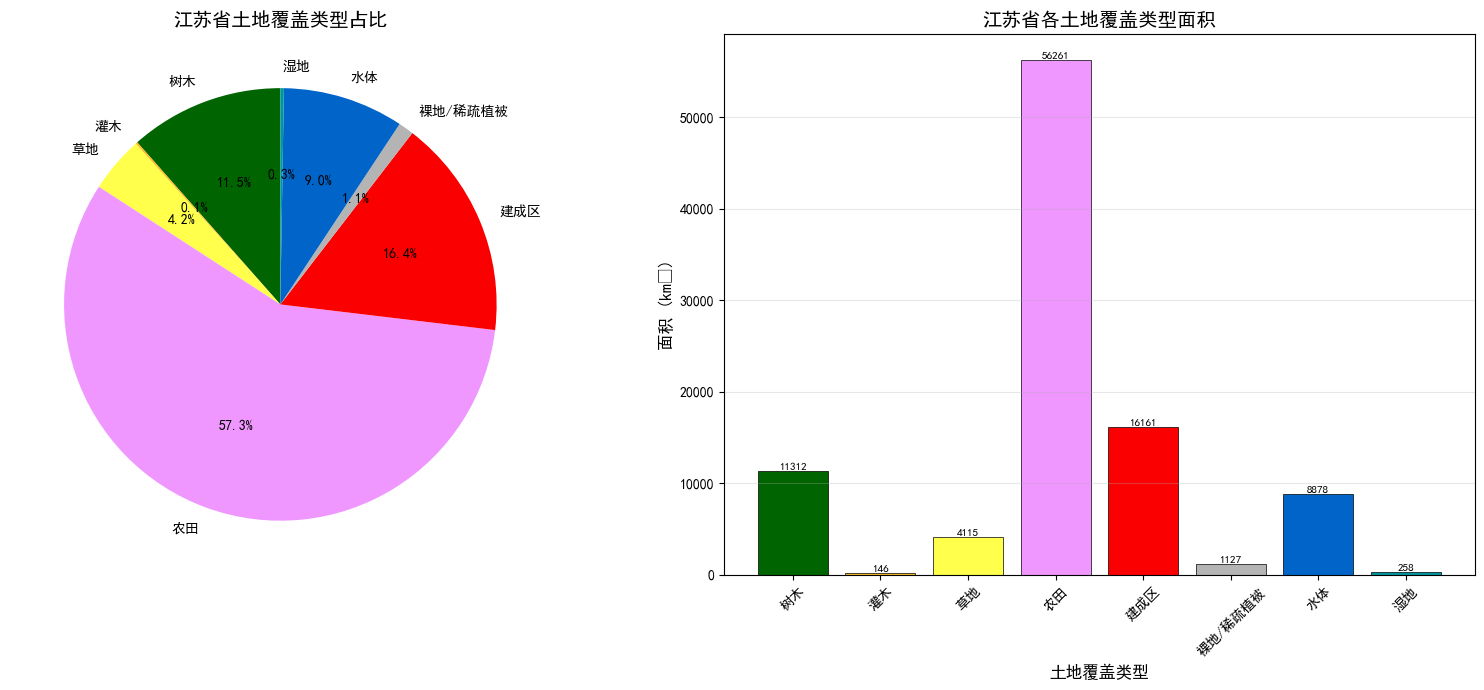

✅ 面积统计图已保存


In [ ]:

# ============================================
# 4.5 绘制面积统计图
# ============================================

if areas:
    # 过滤掉面积为0的类别
    areas_filtered = {k: v for k, v in areas.items() if v > 100}

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # 饼图
    labels = list(areas_filtered.keys())
    values = list(areas_filtered.values())
    colors_list = ['#006400', '#ffbb22', '#ffff4c', '#f096ff',
                   '#fa0000', '#b4b4b4', '#0064c8', '#0096a0'][:len(labels)]

    wedges, texts, autotexts = ax1.pie(
        values, labels=labels, colors=colors_list,
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 10}
    )
    ax1.set_title('江苏省土地覆盖类型占比', fontsize=14, fontweight='bold')

    # 柱状图
    bars = ax2.bar(labels, values, color=colors_list, edgecolor='black', linewidth=0.5)
    ax2.set_xlabel('土地覆盖类型', fontsize=12)
    ax2.set_ylabel('面积 (km²)', fontsize=12)
    ax2.set_title('江苏省各土地覆盖类型面积', fontsize=14, fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)

    # 在柱子上添加数值
    for bar, val in zip(bars, values):
        ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{val:.0f}', ha='center', va='bottom', fontsize=8)

    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('landcover_stats.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ 面积统计图已保存")

---

## 第五章：矢量数据处理与空间分析

### 5.1 学习目标

- 加载和处理矢量数据
- 进行空间统计分析
- 实现区域统计（Zonal Statistics）


In [ ]:
import ee
import geemap
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd
import json
import os

matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

ee.Initialize(project='ee-xyt556')

geojson_path = r"D:\soft\geo_program\geog-510\book\geospatial\data\province.geojson"

# ============================================================
# Step 1：检查文件是否存在
# ============================================================
if not os.path.exists(geojson_path):
    raise FileNotFoundError(f"❌ 文件不存在：{geojson_path}")
print(f"✅ 文件存在：{geojson_path}")

# ============================================================
# Step 2：用 geopandas 读取（最稳健）
# ============================================================
gdf = gpd.read_file(geojson_path)
print(f"\n📊 原始数据信息：")
print(f"  行数       : {len(gdf)}")
print(f"  字段列表   : {list(gdf.columns)}")
print(f"  几何类型   : {gdf.geometry.geom_type.unique()}")
print(f"  坐标参考系 : {gdf.crs}")
print(gdf.head())

# ============================================================
# Step 3：修复坐标系
# ============================================================
if gdf.crs is None:
    print("\n⚠️ 未检测到 CRS，默认设置为 EPSG:4326")
    gdf = gdf.set_crs("EPSG:4326")
elif gdf.crs.to_epsg() != 4326:
    print(f"\n⚠️ CRS={gdf.crs}，重投影到 EPSG:4326...")
    gdf = gdf.to_crs("EPSG:4326")
print(f"✅ CRS：{gdf.crs}")

# ============================================================
# Step 4：清除无效几何
# ============================================================
before = len(gdf)
gdf = gdf[gdf.geometry.notna()]          # 去除空几何
gdf = gdf[gdf.geometry.is_valid]         # 去除无效几何
after = len(gdf)

if before != after:
    print(f"⚠️ 已移除 {before - after} 条无效记录，剩余 {after} 条")
else:
    print(f"✅ 所有 {after} 条几何均有效")

# ============================================================
# Step 5：转为标准 GeoJSON 字典
# ============================================================
geojson_dict = json.loads(gdf.to_json())

print(f"\n✅ GeoJSON 类型  : {geojson_dict['type']}")
print(f"✅ 要素数量      : {len(geojson_dict['features'])}")

# 查看第一个要素结构（调试用）
first_feature = geojson_dict["features"][0]
print(f"\n📌 第一个要素：")
print(f"  几何类型   : {first_feature['geometry']['type']}")
print(f"  坐标       : {first_feature['geometry']['coordinates']}")
print(f"  属性字段   : {list(first_feature['properties'].keys())}")

# ============================================================
# Step 6：转换为 EE FeatureCollection
# ============================================================
cities_ee = geemap.geojson_to_ee(geojson_dict)

print(f"\n🎉 转换成功！")
print(f"城市数量 : {cities_ee.size().getInfo()}")
print(f"城市属性 : {cities_ee.first().propertyNames().getInfo()}")

# ============================================================
# Step 7：可视化
# ============================================================
Map2 = geemap.Map(center=[35.8617, 104.1954], zoom=4)
Map2.addLayer(cities_ee, {'color': 'red'}, '主要城市')
Map2.add_layer_control()
Map2

✅ 文件存在：D:\soft\geo_program\geog-510\book\geospatial\data\province.geojson

📊 原始数据信息：
  行数       : 34
  字段列表   : ['省', '省代码', 'geometry']
  几何类型   : <ArrowStringArray>
['MultiPolygon']
Length: 1, dtype: str
  坐标参考系 : EPSG:4326
     省     省代码                                           geometry
0  河南省  410000  MULTIPOLYGON Z (((111.02261 33.17939 0, 111.00...
1  浙江省  330000  MULTIPOLYGON Z (((121.08199 27.47084 0, 121.09...
2  海南省  460000  MULTIPOLYGON Z (((112.05623 3.83753 0, 112.042...
3  台湾省  710000  MULTIPOLYGON Z (((121.60056 22.02062 0, 121.59...
4  甘肃省  620000  MULTIPOLYGON Z (((97.17195 42.79342 0, 97.8451...
✅ CRS：EPSG:4326
⚠️ 已移除 1 条无效记录，剩余 33 条

✅ GeoJSON 类型  : FeatureCollection
✅ 要素数量      : 33

📌 第一个要素：
  几何类型   : MultiPolygon
  坐标       : [[[[111.02260599966735, 33.17939399973346, 0.0], [111.00594300016951, 33.171004999581214, 0.0], [111.0105749997366, 33.18506599959636, 0.0], [111.02208700001523, 33.191077999849995, 0.0], [111.02500899986563, 33.18626800016824, 0.0], [111.0

Exception: Invalid GeoJSON geometry.


### 5.2 实践程序

In [ ]:
# ============================================
# 第五章：矢量数据处理与空间分析
# ============================================

import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, Polygon
import json

matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

ee.Initialize(project='ee-xyt556')

# ============================================
# 5.1 加载 GEE 内置矢量数据
# ============================================

Map = geemap.Map(center=[35.8617, 104.1954], zoom=4)

# 加载中国省级行政边界
china_provinces = (ee.FeatureCollection('FAO/GAUL/2015/level1')
                   .filter(ee.Filter.eq('ADM0_NAME', 'China')))

# 加载世界国家边界
world_countries = ee.FeatureCollection('USDOS/LSIB_SIMPLE/2017')
china = world_countries.filter(ee.Filter.eq('country_na', 'China'))

# 可视化
Map.addLayer(china_provinces, {'color': 'blue', 'fillColor': '00000000'}, '中国省份')
Map.addLayer(china, {'color': 'red', 'fillColor': '00000000', 'width': 2}, '中国国界')

# 查看属性信息
print("省级数据属性:")
print(china_provinces.first().propertyNames().getInfo())
print(f"\n省份数量: {china_provinces.size().getInfo()}")

Map


省级数据属性:
['Shape_Leng', 'ADM1_CODE', 'STATUS', 'ADM0_NAME', 'ADM0_CODE', 'EXP1_YEAR', 'Shape_Area', 'system:index', 'ADM1_NAME', 'STR1_YEAR', 'DISP_AREA']

省份数量: 31


Map(center=[35.8617, 104.1954], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topr…

In [ ]:

# ============================================
# 5.2 本地 Shapefile 加载
# ============================================

# 方法1：使用 geemap 直接上传（在Jupyter中）
# shp_path = '/path/to/your/shapefile.shp'
# features = geemap.shp_to_ee(shp_path)

# 方法2：从 GeoJSON 加载
# 创建示例 GeoJSON 数据（主要城市）
cities_geojson = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {"name": "北京", "population": 21893095, "type": "直辖市"},
            "geometry": {"type": "Point", "coordinates": [116.4074, 39.9042]}
        },
        {
            "type": "Feature",
            "properties": {"name": "上海", "population": 24870895, "type": "直辖市"},
            "geometry": {"type": "Point", "coordinates": [121.4737, 31.2304]}
        },
        {
            "type": "Feature",
            "properties": {"name": "广州", "population": 18676605, "type": "省会"},
            "geometry": {"type": "Point", "coordinates": [113.2644, 23.1291]}
        },
        {
            "type": "Feature",
            "properties": {"name": "成都", "population": 20937757, "type": "省会"},
            "geometry": {"type": "Point", "coordinates": [104.0668, 30.5728]}
        },
        {
            "type": "Feature",
            "properties": {"name": "武汉", "population": 13648000, "type": "省会"},
            "geometry": {"type": "Point", "coordinates": [114.3054, 30.5928]}
        },
        {
            "type": "Feature",
            "properties": {"name": "西安", "population": 12952000, "type": "省会"},
            "geometry": {"type": "Point", "coordinates": [108.9402, 34.3416]}
        }
    ]
}

# 转换为 EE FeatureCollection
cities_ee = geemap.geojson_to_ee(cities_geojson)
print(f"城市数量: {cities_ee.size().getInfo()}")
print(f"城市属性: {cities_ee.first().propertyNames().getInfo()}")

# 可视化城市点
Map2 = geemap.Map(center=[35.8617, 104.1954], zoom=4)
Map2.addLayer(china_provinces, {'color': 'gray', 'fillColor': 'EEEEEE'}, '省份')
Map2.addLayer(cities_ee, {'color': 'red'}, '主要城市')
Map2.add_layer_control()
Map2


城市数量: 6
城市属性: ['system:index', 'name', 'type', 'population']


Map(center=[35.8617, 104.1954], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topr…

In [ ]:

# ============================================
# 5.3 区域统计分析（Zonal Statistics）
# ============================================

# 加载 NDVI 数据
ndvi_image = (ee.ImageCollection('MODIS/006/MOD13A2')
              .filterDate('2022-06-01', '2022-09-30')
              .select('NDVI')
              .mean()
              .multiply(0.0001))  # 缩放因子

# 对中国各省计算平均NDVI
province_ndvi = ndvi_image.reduceRegions(
    collection=china_provinces,
    reducer=ee.Reducer.mean().combine(
        ee.Reducer.stdDev(), sharedInputs=True
    ).combine(
        ee.Reducer.minMax(), sharedInputs=True
    ),
    scale=1000,
    crs='EPSG:4326'
)

# 提取结果
result_list = province_ndvi.select(
    ['ADM1_NAME', 'mean', 'stdDev', 'min', 'max']
).getInfo()

# 转换为DataFrame
rows = []
for feature in result_list['features']:
    props = feature['properties']
    rows.append({
        '省份': props.get('ADM1_NAME', ''),
        '平均NDVI': round(props.get('mean', 0) or 0, 4),
        '标准差': round(props.get('stdDev', 0) or 0, 4),
        '最小NDVI': round(props.get('min', 0) or 0, 4),
        '最大NDVI': round(props.get('max', 0) or 0, 4)
    })

df_ndvi = pd.DataFrame(rows)
df_ndvi = df_ndvi[df_ndvi['平均NDVI'] > 0].sort_values('平均NDVI', ascending=False)

print("各省平均NDVI排名：")
print(df_ndvi.to_string(index=False))


各省平均NDVI排名：
                      省份  平均NDVI    标准差  最小NDVI  最大NDVI
      Heilongjiang Sheng  0.7698 0.1087 -0.2000  0.9280
            Hainan Sheng  0.7504 0.1197 -0.1075  0.9241
             Jilin Sheng  0.7476 0.1346 -0.1997  0.9257
          Liaoning Sheng  0.7426 0.1103 -0.1825  0.9313
            Fujian Sheng  0.7305 0.1231 -0.1928  0.9224
             Beijing Shi  0.7083 0.1442 -0.1876  0.9137
           Guizhou Sheng  0.7036 0.0775 -0.1128  0.8977
             Hunan Sheng  0.7028 0.1016 -0.1720  0.9071
             Hubei Sheng  0.6954 0.1332 -0.1780  0.9180
           Jiangxi Sheng  0.6933 0.1341 -0.1935  0.9224
          Zhejiang Sheng  0.6886 0.1631 -0.1974  0.9288
Guangxi Zhuangzu Zizhiqu  0.6867 0.0927 -0.0434  0.9125
           Shaanxi Sheng  0.6745 0.1692 -0.1166  0.9296
           Chongqing Shi  0.6681 0.1066 -0.1002  0.9121
         Guangdong Sheng  0.6628 0.1455 -0.1928  0.9874
             Hebei Sheng  0.6616 0.1241 -0.1876  0.9194
            Shanxi Sheng  0.6485 0.1

In [ ]:

# ============================================
# 5.4 可视化省级NDVI差异
# ============================================

Map3 = geemap.Map(center=[35.8617, 104.1954], zoom=4)

# NDVI 可视化
ndvi_vis = {
    'min': 0, 'max': 0.8,
    'palette': ['#d73027', '#fc8d59', '#fee08b',
                '#91cf60', '#1a9850', '#006837']
}
Map3.addLayer(ndvi_image.clip(china), ndvi_vis, '全国NDVI')
Map3.addLayer(china_provinces, {'color': 'black', 'fillColor': '00000000'}, '省界')

# 添加颜色条
Map3.add_colorbar(ndvi_vis, label='NDVI值', position='bottomleft')
Map3


Map(center=[35.8617, 104.1954], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topr…

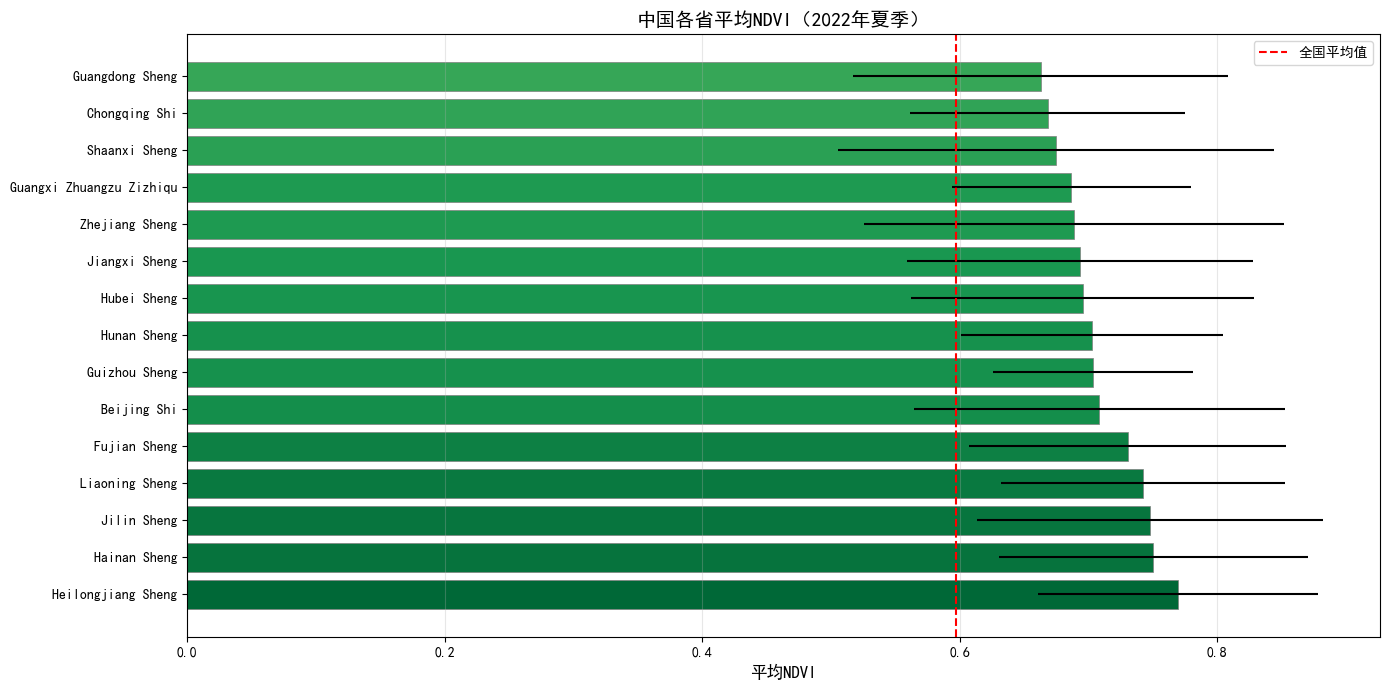

✅ 省级NDVI统计图已保存


In [ ]:

# ============================================
# 5.5 绘制省级NDVI统计图
# ============================================

if len(df_ndvi) > 0:
    # 选择前15个省份
    df_top = df_ndvi.head(15)

    fig, ax = plt.subplots(figsize=(14, 7))

    colors = plt.cm.RdYlGn(
        [v/df_top['平均NDVI'].max() for v in df_top['平均NDVI']]
    )

    bars = ax.barh(df_top['省份'], df_top['平均NDVI'],
                   xerr=df_top['标准差'], color=colors,
                   edgecolor='gray', linewidth=0.5)

    ax.set_xlabel('平均NDVI', fontsize=12)
    ax.set_title('中国各省平均NDVI（2022年夏季）', fontsize=14, fontweight='bold')
    ax.axvline(x=df_ndvi['平均NDVI'].mean(), color='red',
               linestyle='--', label='全国平均值')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig('province_ndvi.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ 省级NDVI统计图已保存")


In [ ]:

# ============================================
# 5.6 缓冲区分析
# ============================================

Map4 = geemap.Map(center=[116.4074, 39.9042], zoom=9)

# 创建北京故宫缓冲区
gugong = ee.Geometry.Point([116.3912, 39.9163])

# 创建不同半径的缓冲区
buffer_5km = gugong.buffer(5000)    # 5km
buffer_10km = gugong.buffer(10000)  # 10km
buffer_20km = gugong.buffer(20000)  # 20km

# 加载夜间灯光数据（分析城市中心辐射影响）
viirs = (ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG')
         .filterDate('2022-01-01', '2022-12-31')
         .select('avg_rad')
         .mean())

Map4.addLayer(viirs, {'min': 0, 'max': 100, 'palette': ['black', 'yellow', 'white']},
              'VIIRS夜间灯光')
Map4.addLayer(ee.Feature(buffer_5km), {'color': 'red', 'fillColor': '00000000'}, '5km缓冲区')
Map4.addLayer(ee.Feature(buffer_10km), {'color': 'orange', 'fillColor': '00000000'}, '10km缓冲区')
Map4.addLayer(ee.Feature(buffer_20km), {'color': 'yellow', 'fillColor': '00000000'}, '20km缓冲区')
Map4.addLayer(gugong, {'color': 'red'}, '故宫中心点')

Map4.add_layer_control()
Map4

Map(center=[116.4074, 39.9042], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topr…

---

## 第六章：变化检测与专题图制作

### 6.1 学习目标

- 实现影像差值变化检测
- 制作专题地图
- 输出地图和分析结果

### 6.2 实践程序

In [ ]:
# ============================================
# 第六章：变化检测与专题图制作
# ============================================

import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

ee.Initialize(project='ee-xyt556')


In [ ]:

# ============================================
# 6.1 城市扩张变化检测（夜间灯光）
# ============================================

# 研究区域：长三角地区
yangtze_delta = ee.Geometry.Rectangle([119.0, 29.5, 123.0, 32.5])

def get_nightlight(year):
    """获取年度夜间灯光数据"""
    return (ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG')
            .filterDate(f'{year}-01-01', f'{year}-12-31')
            .select('avg_rad')
            .mean()
            .clip(yangtze_delta))

# 获取2015和2022年夜间灯光
nl_2015 = get_nightlight(2015)
nl_2022 = get_nightlight(2022)

# 计算变化
nl_change = nl_2022.subtract(nl_2015)
nl_change_pct = nl_change.divide(nl_2015.add(0.001)).multiply(100)

Map = geemap.Map()
Map.centerObject(yangtze_delta, 8)

# 可视化
nl_vis = {'min': 0, 'max': 150, 'palette': ['black', '#1a1a2e', '#16213e',
                                              '#0f3460', '#533483', '#e94560',
                                              'yellow', 'white']}
change_vis = {'min': -50, 'max': 100,
              'palette': ['darkblue', 'blue', 'white', 'orange', 'red']}

Map.addLayer(nl_2015, nl_vis, '2015年夜间灯光')
Map.addLayer(nl_2022, nl_vis, '2022年夜间灯光')
Map.addLayer(nl_change, change_vis, '灯光变化量')

Map.add_colorbar(change_vis, label='灯光变化量(辐射度)', position='bottomleft')
Map.add_layer_control()
Map


Map(center=[31.007528677422215, 121.00000000000006], controls=(WidgetControl(options=['position', 'transparent…

In [ ]:

# ============================================
# 6.2 植被变化检测（NDVI差值法）
# ============================================

# 研究区：内蒙古某地区（防治荒漠化效果）
study_area = ee.Geometry.Rectangle([110.0, 40.0, 115.0, 43.0])

def get_summer_ndvi(year):
    """获取夏季NDVI"""
    collection = (ee.ImageCollection('LANDSAT/LC08/C02/T1_TOA')
                  .filterDate(f'{year}-06-01', f'{year}-08-31')
                  .filterBounds(study_area)
                  .filter(ee.Filter.lt('CLOUD_COVER', 20))
                  .median()
                  .clip(study_area))
    return collection.normalizedDifference(['B5', 'B4']).rename('NDVI')

ndvi_2015 = get_summer_ndvi(2015)
ndvi_2022 = get_summer_ndvi(2022)
ndvi_diff = ndvi_2022.subtract(ndvi_2015).rename('NDVI_Change')

# 变化分类
# 显著改善: > 0.1, 轻微改善: 0.05-0.1, 稳定: -0.05-0.05
# 轻微退化: -0.1-(-0.05), 显著退化: < -0.1
change_classified = (ndvi_diff
    .where(ndvi_diff.gt(0.1), 5)      # 显著改善
    .where(ndvi_diff.gt(0.05).And(ndvi_diff.lte(0.1)), 4)   # 轻微改善
    .where(ndvi_diff.gte(-0.05).And(ndvi_diff.lte(0.05)), 3)  # 稳定
    .where(ndvi_diff.lt(-0.05).And(ndvi_diff.gte(-0.1)), 2)   # 轻微退化
    .where(ndvi_diff.lt(-0.1), 1)     # 显著退化
    .rename('Change_Class'))

Map2 = geemap.Map()
Map2.centerObject(study_area, 7)

# 各类别可视化
ndvi_vis = {'min': -0.1, 'max': 0.8, 'palette': ['brown', 'yellow', 'lightgreen', 'green', 'darkgreen']}
change_vis2 = {'min': -0.3, 'max': 0.3, 'palette': ['red', 'orange', 'white', 'lightgreen', 'darkgreen']}
class_vis = {'min': 1, 'max': 5, 'palette': ['#d73027', '#fc8d59', '#ffffbf', '#91cf60', '#1a9850']}

Map2.addLayer(ndvi_2015, ndvi_vis, '2015年NDVI')
Map2.addLayer(ndvi_2022, ndvi_vis, '2022年NDVI')
Map2.addLayer(ndvi_diff, change_vis2, 'NDVI变化量')
Map2.addLayer(change_classified, class_vis, '变化分类')

# 添加图例
legend_dict = {
    '显著退化(< -0.1)': '#d73027',
    '轻微退化(-0.1~-0.05)': '#fc8d59',
    '基本稳定(-0.05~0.05)': '#ffffbf',
    '轻微改善(0.05~0.1)': '#91cf60',
    '显著改善(> 0.1)': '#1a9850'
}
Map2.add_legend(legend_title='植被变化类型', legend_dict=legend_dict)
Map2.add_colorbar(change_vis2, label='NDVI变化量', position='bottomleft')
Map2.add_layer_control()
Map2


Map(center=[41.515461247363035, 112.50000000000004], controls=(WidgetControl(options=['position', 'transparent…

计算各变化类别面积...
  显著退化: 13365.29 km²
  轻微退化: 15452.92 km²
  基本稳定: 82550.88 km²
  轻微改善: 14164.50 km²
  显著改善: 13524.53 km²


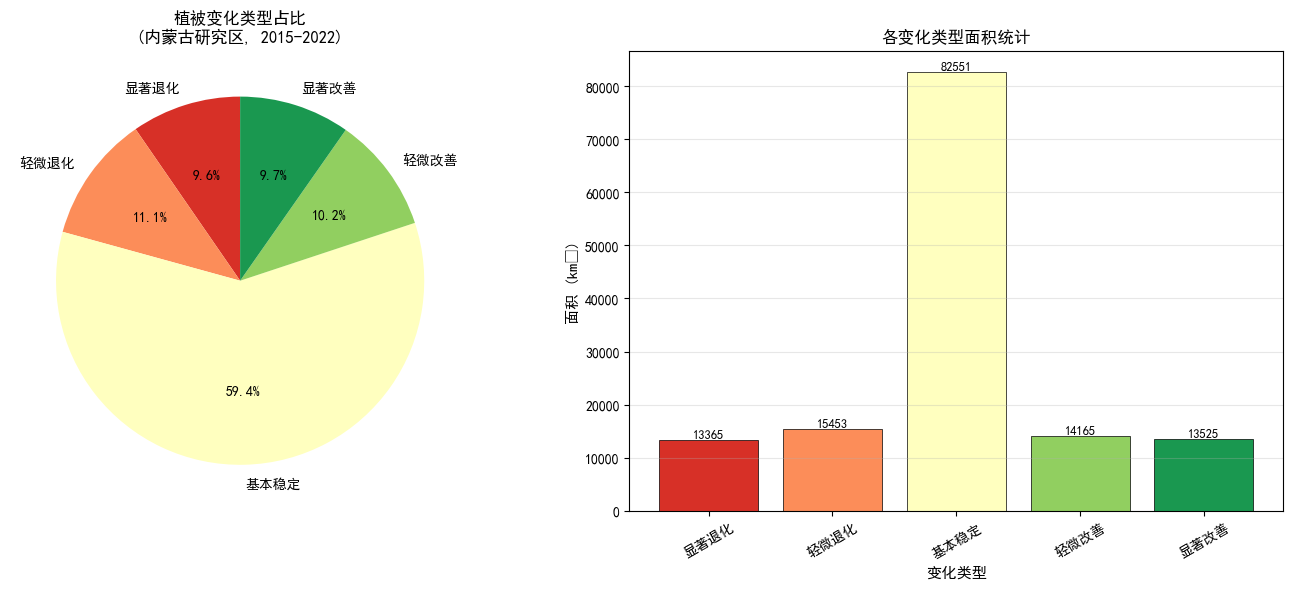

In [ ]:

# ============================================
# 6.3 面积统计与图表
# ============================================

# 统计各变化类别面积
def get_class_area(change_image, class_val, geometry):
    mask = change_image.eq(class_val)
    area = (mask.multiply(ee.Image.pixelArea())
            .reduceRegion(
                reducer=ee.Reducer.sum(),
                geometry=geometry,
                scale=500,  # MODIS尺度
                maxPixels=1e13,
                bestEffort=True
            ).get('Change_Class'))
    result = area.getInfo()
    return (result or 0) / 1e6  # 转换为km²

print("计算各变化类别面积...")
class_names = {
    1: '显著退化',
    2: '轻微退化',
    3: '基本稳定',
    4: '轻微改善',
    5: '显著改善'
}
class_colors = ['#d73027', '#fc8d59', '#ffffbf', '#91cf60', '#1a9850']

areas = {}
for cls, name in class_names.items():
    area = get_class_area(change_classified, cls, study_area)
    areas[name] = area
    print(f"  {name}: {area:.2f} km²")

# 绘制统计图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

names = list(areas.keys())
values = list(areas.values())

# 饼图
wedges, texts, autotexts = ax1.pie(
    values, labels=names, colors=class_colors,
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 10}
)
ax1.set_title('植被变化类型占比\n(内蒙古研究区, 2015-2022)',
              fontsize=12, fontweight='bold')

# 柱状图
bars = ax2.bar(names, values, color=class_colors,
               edgecolor='black', linewidth=0.5)
ax2.set_xlabel('变化类型', fontsize=11)
ax2.set_ylabel('面积 (km²)', fontsize=11)
ax2.set_title('各变化类型面积统计', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=30)

for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{val:.0f}', ha='center', va='bottom', fontsize=9)

ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('vegetation_change.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:

# ============================================
# 6.4 导出地图为图片
# ============================================

# 使用 geemap 截图功能
Map_export = geemap.Map(center=[41.5, 112.5], zoom=7)
Map_export.addLayer(ndvi_2022, ndvi_vis, '2022年NDVI')
Map_export.addLayer(change_classified, class_vis, '变化分类')

# 添加比例尺和北箭头（如果支持）
# Map_export.add.add_scale_control()

# 截图保存
# Map_export.to_image(filename='map_screenshot.png', monitor=1)

# 导出到Google Drive（用于大规模数据）
task = ee.batch.Export.image.toDrive(
    image=ndvi_diff,
    description='NDVI_Change_2015_2022',
    folder='geemap_exports',
    fileNamePrefix='ndvi_change',
    scale=30,
    region=study_area,
    crs='EPSG:4326',
    maxPixels=1e13
)
# task.start()  # 取消注释以开始导出
print("✅ 导出任务已准备（取消注释 task.start() 以执行）")


✅ 导出任务已准备（取消注释 task.start() 以执行）


In [ ]:

# ============================================
# 6.5 生成专题地图 HTML
# ============================================

# 创建完整专题地图
final_map = geemap.Map(center=[41.5, 112.5], zoom=7)

# 添加底图
final_map.add_basemap("TERRAIN")

# 添加数据层
final_map.addLayer(ndvi_2015, ndvi_vis, '2015年NDVI', shown=False)
final_map.addLayer(ndvi_2022, ndvi_vis, '2022年NDVI', shown=False)
final_map.addLayer(ndvi_diff, change_vis2, 'NDVI变化量', shown=False)
final_map.addLayer(change_classified, class_vis, '变化分类', shown=True)

# 添加图例和颜色条
final_map.add_legend(legend_title='植被变化类型', legend_dict=legend_dict)
final_map.add_colorbar(change_vis2, label='NDVI变化量', position='bottomright')
# final_map.add_scale_control()
final_map.add_layer_control()

# 保存为HTML
final_map.save('vegetation_change_map.html')
print("✅ 专题地图已保存为 vegetation_change_map.html")

✅ 专题地图已保存为 vegetation_change_map.html


---

## 第七章：数字高程模型分析

### 7.1 学习目标

- 处理 DEM 数据
- 计算地形参数（坡度、坡向、山体阴影）
- 进行流域分析

### 7.2 实践程序

In [ ]:
# ============================================
# 第七章：数字高程模型分析
# ============================================

import ee
import geemap
import numpy as np
import matplotlib.pyplot as plt

matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

ee.Initialize(project='ee-xyt556')


In [ ]:

# ============================================
# 7.1 DEM 数据加载与基础分析
# ============================================

# 研究区：四川盆地及周边山地
sichuan = ee.Geometry.Rectangle([101.0, 28.0, 109.0, 34.0])

# 加载 SRTM DEM（30m分辨率）
srtm = ee.Image('USGS/SRTMGL1_003').clip(sichuan)

# 加载 ALOS DEM（30m分辨率，更高精度）
alos = ee.ImageCollection('JAXA/ALOS/AW3D30/V3_2') \
         .select('DSM') \
         .mosaic() \
         .clip(sichuan)

Map = geemap.Map()
Map.centerObject(sichuan, 7)

# 高程可视化
elev_vis = {
    'min': 200, 'max': 6000,
    'palette': ['#006633', '#E5FFCC', '#99CC00',
                '#CC9900', '#996633', '#663300',
                '#CCCCCC', '#FFFFFF']
}
Map.addLayer(srtm, elev_vis, 'SRTM高程')
Map.addLayer(alos, {'min': 200, 'max': 6000, 'palette': elev_vis['palette']},
             'ALOS高程')

# 添加颜色条
Map.add_colorbar(elev_vis, label='海拔高度 (m)', position='bottomleft')
Map.add_layer_control()
Map


Map(center=[31.02991740591136, 105], controls=(WidgetControl(options=['position', 'transparent_bg'], position=…

In [ ]:
# ============================================
# 7.2 地形参数计算
# ============================================

# 计算坡度（度）
slope = ee.Terrain.slope(srtm).rename('Slope')

# 计算坡向（度，0-360，0为正北方向）
aspect = ee.Terrain.aspect(srtm).rename('Aspect')

# 计算山体阴影
hillshade = ee.Terrain.hillshade(srtm, azimuth=315, elevation=45).rename('Hillshade')

# 计算地形湿度指数 (TWI)
def compute_twi(dem):
    """计算地形湿度指数 TWI = ln(a / tan(β))"""
    slope_rad = ee.Terrain.slope(dem).multiply(np.pi / 180)

    # 简化的汇水面积代理
    flow_acc = slope_rad.multiply(-1).add(10)

    tan_slope = slope_rad.tan().max(ee.Image.constant(0.001))
    twi = flow_acc.divide(tan_slope).log().rename('TWI')
    return twi

twi = compute_twi(srtm)

# 计算地形粗糙度指数 (TRI)
def compute_tri(dem, kernel_size=3):
    """地形粗糙度指数"""
    kernel = ee.Kernel.square(kernel_size)
    max_val = dem.reduceNeighborhood(ee.Reducer.max(), kernel)
    min_val = dem.reduceNeighborhood(ee.Reducer.min(), kernel)
    tri = max_val.subtract(min_val).rename('TRI')
    return tri

tri = compute_tri(srtm)

Map2 = geemap.Map()
Map2.centerObject(sichuan, 7)

# 坡度可视化
slope_vis = {
    'min': 0,
    'max': 60,
    'palette': ['white', 'yellow', 'orange', 'red', 'darkred']
}
Map2.addLayer(slope, slope_vis, '坡度(度)')

# 坡向可视化
aspect_vis = {
    'min': 0,
    'max': 360,
    'palette': ['blue', 'cyan', 'green', 'yellow', 'red', 'blue']
}
Map2.addLayer(aspect, aspect_vis, '坡向(度)')

# 山体阴影
Map2.addLayer(hillshade, {'min': 0, 'max': 255, 'palette': ['black', 'white']}, '山体阴影')

# 地形粗糙度
Map2.addLayer(
    tri,
    {'min': 0, 'max': 500, 'palette': ['green', 'yellow', 'orange', 'red']},
    '地形粗糙度(TRI)'
)

# 叠加山体阴影的高程图（修正版）
elev_3d = srtm.visualize(**elev_vis)

# 归一化阴影，避免图像过暗
shade = hillshade.divide(255).multiply(0.7).add(0.3)

# 单波段阴影乘以RGB高程图
blended = elev_3d.multiply(shade)

Map2.addLayer(blended, {}, '立体高程图')

Map2.add_colorbar(slope_vis, label='坡度(°)', position='bottomleft')
Map2.add_layer_control()
Map2

Map(center=[31.02991740591136, 105], controls=(WidgetControl(options=['position', 'transparent_bg'], position=…

计算各高程区间面积（请稍候）...
  平原(< 500m): 113110.10 km²
  丘陵(500-1000m): 115276.16 km²
  低山(1000-2000m): 106161.16 km²
  中山(2000-3500m): 77744.47 km²
  高山(3500-5000m): 91637.32 km²
  极高山(> 5000m): 746.94 km²


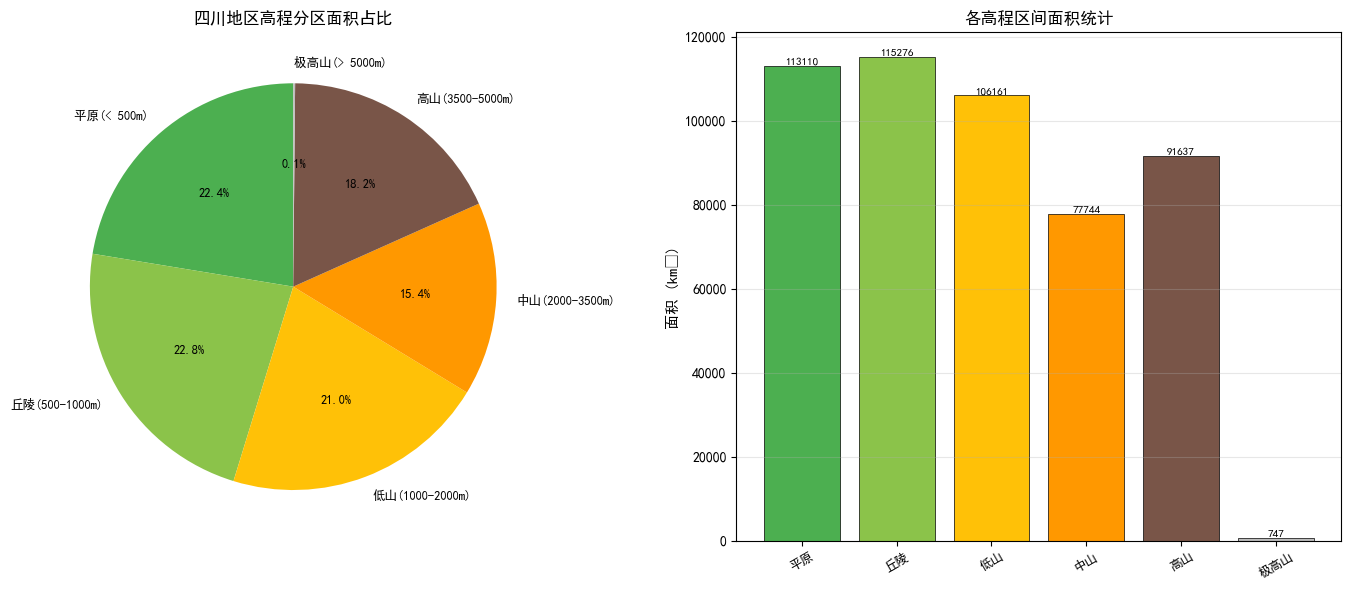

In [ ]:

# ============================================
# 7.3 高程分区统计
# ============================================

# 定义高程区间
elevation_zones = {
    '平原(< 500m)': (0, 500),
    '丘陵(500-1000m)': (500, 1000),
    '低山(1000-2000m)': (1000, 2000),
    '中山(2000-3500m)': (2000, 3500),
    '高山(3500-5000m)': (3500, 5000),
    '极高山(> 5000m)': (5000, 9000)
}

def calculate_zone_area(dem, min_elev, max_elev, region):
    """计算特定高程区间的面积"""
    mask = dem.gte(min_elev).And(dem.lt(max_elev))
    area = (mask.multiply(ee.Image.pixelArea())
            .reduceRegion(
                reducer=ee.Reducer.sum(),
                geometry=region,
                scale=100,
                maxPixels=1e13,
                bestEffort=True
            ).get('elevation'))
    result = area.getInfo()
    return (result or 0) / 1e6  # km²

print("计算各高程区间面积（请稍候）...")
zone_areas = {}
for zone_name, (min_e, max_e) in elevation_zones.items():
    area = calculate_zone_area(srtm, min_e, max_e, sichuan)
    zone_areas[zone_name] = area
    print(f"  {zone_name}: {area:.2f} km²")

# 绘制高程分区图
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

zone_colors = ['#4CAF50', '#8BC34A', '#FFC107', '#FF9800', '#795548', '#BDBDBD']
zones = list(zone_areas.keys())
areas = list(zone_areas.values())

# 饼图
axes[0].pie(areas, labels=zones, colors=zone_colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9})
axes[0].set_title('四川地区高程分区面积占比', fontsize=12, fontweight='bold')

# 柱状图
bars = axes[1].bar(range(len(zones)), areas, color=zone_colors,
                    edgecolor='black', linewidth=0.5)
axes[1].set_xticks(range(len(zones)))
axes[1].set_xticklabels([z.split('(')[0] for z in zones], rotation=30, fontsize=9)
axes[1].set_ylabel('面积 (km²)', fontsize=11)
axes[1].set_title('各高程区间面积统计', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

for bar, area in zip(bars, areas):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{area:.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('elevation_stats.png', dpi=150, bbox_inches='tight')
plt.show()



计算坡度分级面积...
  平坦(0-5°): 73099.16 km²
  缓坡(5-15°): 127029.16 km²
  斜坡(15-25°): 127880.32 km²
  陡坡(25-35°): 112370.40 km²
  急坡(35-45°): 53871.06 km²
  险坡(>45°): 10257.46 km²


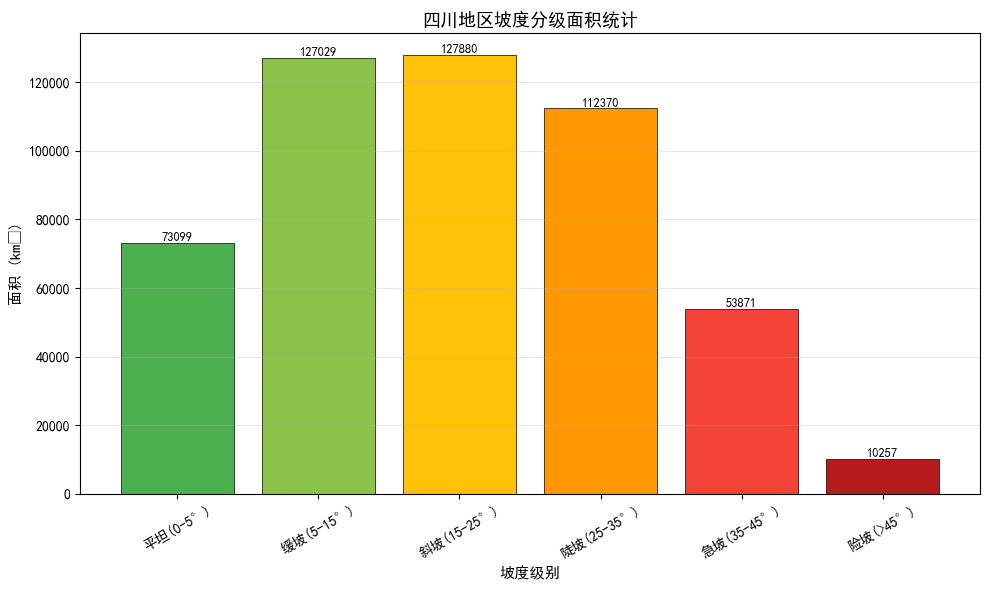

✅ 地形分析图表已保存


In [ ]:

# ============================================
# 7.4 坡度分级统计
# ============================================

# 坡度分级
slope_classes = {
    '平坦(0-5°)': (0, 5),
    '缓坡(5-15°)': (5, 15),
    '斜坡(15-25°)': (15, 25),
    '陡坡(25-35°)': (25, 35),
    '急坡(35-45°)': (35, 45),
    '险坡(>45°)': (45, 90)
}

print("\n计算坡度分级面积...")
slope_areas = {}
for class_name, (min_s, max_s) in slope_classes.items():
    mask = slope.gte(min_s).And(slope.lt(max_s))
    area = (mask.multiply(ee.Image.pixelArea())
            .reduceRegion(
                reducer=ee.Reducer.sum(),
                geometry=sichuan,
                scale=100,
                maxPixels=1e13,
                bestEffort=True
            ).get('Slope'))
    area_val = (area.getInfo() or 0) / 1e6
    slope_areas[class_name] = area_val
    print(f"  {class_name}: {area_val:.2f} km²")

# 绘制坡度统计图
fig, ax = plt.subplots(figsize=(10, 6))
slope_colors = ['#4CAF50', '#8BC34A', '#FFC107', '#FF9800', '#F44336', '#B71C1C']
bars = ax.bar(list(slope_areas.keys()), list(slope_areas.values()),
               color=slope_colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('坡度级别', fontsize=11)
ax.set_ylabel('面积 (km²)', fontsize=11)
ax.set_title('四川地区坡度分级面积统计', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.3, axis='y')

for bar, area in zip(bars, slope_areas.values()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{area:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('slope_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 地形分析图表已保存")

---

## 第八章：综合实战项目

### 8.1 项目描述

**项目名称**：城市热岛效应监测与分析系统  
**研究区域**：北京市  
**分析内容**：  
- 地表温度反演
- 热岛效应空间分布
- 与土地利用的关系分析
- 多年变化趋势

### 8.2 完整实战程序

In [ ]:
# ============================================
# 第八章：综合实战 - 城市热岛效应分析系统
# ============================================

import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

ee.Initialize(project='ee-xyt556')

print("=" * 60)
print("  城市热岛效应监测与分析系统")
print("  基于 Google Earth Engine & Geemap")
print("=" * 60)


  城市热岛效应监测与分析系统
  基于 Google Earth Engine & Geemap


In [ ]:

# ============================================
# 8.1 数据准备与参数设置
# ============================================

# 研究区域：北京市
beijing_roi = ee.Geometry.Rectangle([115.7, 39.4, 117.4, 41.1])
beijing_center = [40.0, 116.5]

# 分析年份
years = [2015, 2017, 2019, 2021, 2023]
analysis_season = {'start_month': '06', 'end_month': '08', 'name': '夏季'}

print(f"研究区域: 北京市")
print(f"分析时段: {years[0]}-{years[-1]}年夏季")
print(f"空间分辨率: 30m (Landsat 8/9)")


研究区域: 北京市
分析时段: 2015-2023年夏季
空间分辨率: 30m (Landsat 8/9)


In [ ]:

# ============================================
# 8.2 地表温度反演函数
# ============================================

def get_lst(year, start_month='06', end_month='08'):
    """
    从Landsat 8/9 反演地表温度 (LST)
    使用单窗口算法
    """
    # 选择卫星
    if year >= 2022:
        collection_id = 'LANDSAT/LC09/C02/T1_L2'
        thermal_band = 'ST_B10'
    else:
        collection_id = 'LANDSAT/LC08/C02/T1_L2'
        thermal_band = 'ST_B10'

    # 云掩膜函数
    def mask_clouds(image):
        qa = image.select('QA_PIXEL')
        cloud_mask = qa.bitwiseAnd(1 << 3).eq(0)  # 无云
        shadow_mask = qa.bitwiseAnd(1 << 4).eq(0)  # 无阴影
        return image.updateMask(cloud_mask).updateMask(shadow_mask)

    # 加载并处理影像
    collection = (ee.ImageCollection(collection_id)
                  .filterDate(f'{year}-{start_month}-01', f'{year}-{end_month}-30')
                  .filterBounds(beijing_roi)
                  .filter(ee.Filter.lt('CLOUD_COVER', 20))
                  .map(mask_clouds))

    if collection.size().getInfo() == 0:
        print(f"  ⚠️  {year}年无可用影像")
        return None

    # 计算LST（开尔文转摄氏度）
    lst = (collection.select(thermal_band)
           .mean()
           .multiply(0.00341802)
           .add(149.0)
           .subtract(273.15)  # K to °C
           .rename('LST')
           .clip(beijing_roi))

    return lst


In [ ]:

# ============================================
# 8.3 计算多年LST
# ============================================

print("\n计算各年度地表温度...")
lst_dict = {}
for year in years:
    print(f"  处理 {year} 年...")
    lst = get_lst(year)
    if lst is not None:
        lst_dict[year] = lst
        print(f"    ✅ {year} 年LST计算完成")



计算各年度地表温度...
  处理 2015 年...
    ✅ 2015 年LST计算完成
  处理 2017 年...
    ✅ 2017 年LST计算完成
  处理 2019 年...
    ✅ 2019 年LST计算完成
  处理 2021 年...
    ✅ 2021 年LST计算完成
  处理 2023 年...
    ✅ 2023 年LST计算完成


In [ ]:

# ============================================
# 8.4 可视化地表温度
# ============================================

Map = geemap.Map(center=beijing_center, zoom=9)

# LST 色彩方案（蓝-白-红）
lst_palette = ['#313695', '#4575b4', '#74add1', '#abd9e9', '#e0f3f8',
               '#ffffbf', '#fee090', '#fdae61', '#f46d43', '#d73027', '#a50026']
lst_vis = {'min': 20, 'max': 55, 'palette': lst_palette}

# 添加各年度LST
for year, lst in lst_dict.items():
    shown = (year == years[-1])  # 默认显示最新年份
    Map.addLayer(lst, lst_vis, f'{year}年夏季LST', shown=shown)

# 添加北京行政边界
beijing_boundary = (ee.FeatureCollection('FAO/GAUL/2015/level1')
                    .filter(ee.Filter.eq('ADM1_NAME', 'Beijing')))
Map.addLayer(beijing_boundary, {'color': 'black', 'fillColor': '00000000', 'width': 2},
             '北京行政边界')

# 颜色条和图例
Map.add_colorbar(lst_vis, label='地表温度 (°C)', position='bottomleft')
Map.add_layer_control()
Map


Map(center=[40.0, 116.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [ ]:

# ============================================
# 8.5 热岛强度计算
# ============================================

def compute_uhi_intensity(lst, rural_buffer=50000):
    """
    计算城市热岛强度 (UHI)
    UHI = T_urban - T_rural
    """
    # 定义城市中心区域（用夜间灯光阈值）
    viirs = (ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG')
             .filterDate('2022-01-01', '2022-12-31')
             .select('avg_rad')
             .mean())

    # 城市区域（灯光值>30的区域）
    urban_mask = viirs.gt(30).clip(beijing_roi)

    # 郊区区域（灯光值<5的区域）
    rural_mask = viirs.lt(5).clip(beijing_roi)

    # 计算城市平均温度
    urban_lst = lst.updateMask(urban_mask)
    rural_lst = lst.updateMask(rural_mask)

    urban_temp = urban_lst.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=beijing_roi,
        scale=500,
        bestEffort=True
    ).get('LST').getInfo()

    rural_temp = rural_lst.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=beijing_roi,
        scale=500,
        bestEffort=True
    ).get('LST').getInfo()

    if urban_temp and rural_temp:
        uhi = urban_temp - rural_temp
        return urban_temp, rural_temp, uhi
    return None, None, None

print("\n计算城市热岛强度...")
uhi_data = []
for year, lst in lst_dict.items():
    urban_t, rural_t, uhi = compute_uhi_intensity(lst)
    if uhi is not None:
        uhi_data.append({
            'year': year,
            'urban_temp': round(urban_t, 2),
            'rural_temp': round(rural_t, 2),
            'uhi_intensity': round(uhi, 2)
        })
        print(f"  {year}: 城区={urban_t:.2f}°C, 郊区={rural_t:.2f}°C, UHI={uhi:.2f}°C")

df_uhi = pd.DataFrame(uhi_data)
print("\nUHI数据汇总：")
print(df_uhi.to_string(index=False))



计算城市热岛强度...
  2015: 城区=39.95°C, 郊区=34.66°C, UHI=5.29°C
  2017: 城区=44.26°C, 郊区=34.98°C, UHI=9.27°C
  2019: 城区=41.84°C, 郊区=33.51°C, UHI=8.33°C
  2021: 城区=40.75°C, 郊区=32.71°C, UHI=8.05°C
  2023: 城区=44.78°C, 郊区=36.35°C, UHI=8.42°C

UHI数据汇总：
 year  urban_temp  rural_temp  uhi_intensity
 2015       39.95       34.66           5.29
 2017       44.26       34.98           9.27
 2019       41.84       33.51           8.33
 2021       40.75       32.71           8.05
 2023       44.78       36.35           8.42


In [ ]:

# ============================================
# 8.6 热岛分级分析
# ============================================

# 使用最新年份进行热岛分级
latest_year = max(lst_dict.keys())
latest_lst = lst_dict[latest_year]

# 计算LST统计值
lst_stats = latest_lst.reduceRegion(
    reducer=ee.Reducer.mean().combine(
        ee.Reducer.stdDev(), sharedInputs=True
    ),
    geometry=beijing_roi,
    scale=500,
    bestEffort=True
).getInfo()

mean_lst = lst_stats.get('LST_mean', 35)
std_lst = lst_stats.get('LST_stdDev', 5)

print(f"\n{latest_year}年LST统计：均值={mean_lst:.2f}°C, 标准差={std_lst:.2f}°C")

# 热岛分级（基于均值±标准差）
def classify_uhi(lst_image, mean, std):
    """
    热岛分级：
    1. 强冷岛: < mean - 2*std
    2. 冷岛: mean - 2*std ~ mean - std
    3. 较冷: mean - std ~ mean - 0.5*std
    4. 正常: mean - 0.5*std ~ mean + 0.5*std
    5. 较热: mean + 0.5*std ~ mean + std
    6. 热岛: mean + std ~ mean + 2*std
    7. 强热岛: > mean + 2*std
    """
    return (lst_image
            .where(lst_image.lt(mean - 2*std), 1)
            .where(lst_image.gte(mean - 2*std).And(lst_image.lt(mean - std)), 2)
            .where(lst_image.gte(mean - std).And(lst_image.lt(mean - 0.5*std)), 3)
            .where(lst_image.gte(mean - 0.5*std).And(lst_image.lt(mean + 0.5*std)), 4)
            .where(lst_image.gte(mean + 0.5*std).And(lst_image.lt(mean + std)), 5)
            .where(lst_image.gte(mean + std).And(lst_image.lt(mean + 2*std)), 6)
            .where(lst_image.gte(mean + 2*std), 7)
            .rename('UHI_Class'))

uhi_classified = classify_uhi(latest_lst, mean_lst, std_lst)

# 可视化热岛分级
Map2 = geemap.Map(center=beijing_center, zoom=9)
Map2.add_basemap("SATELLITE")

uhi_class_vis = {
    'min': 1, 'max': 7,
    'palette': ['#0000FF', '#4169E1', '#87CEEB', '#90EE90', '#FFA500', '#FF4500', '#8B0000']
}
Map2.addLayer(uhi_classified, uhi_class_vis, '热岛分级')
Map2.addLayer(beijing_boundary, {'color': 'white', 'fillColor': '00000000'}, '北京边界')

uhi_legend = {
    '强冷岛(< μ-2σ)': '#0000FF',
    '冷岛(μ-2σ ~ μ-σ)': '#4169E1',
    '较冷(μ-σ ~ μ-0.5σ)': '#87CEEB',
    '正常(μ±0.5σ)': '#90EE90',
    '较热(μ+0.5σ ~ μ+σ)': '#FFA500',
    '热岛(μ+σ ~ μ+2σ)': '#FF4500',
    '强热岛(> μ+2σ)': '#8B0000'
}
Map2.add_legend(legend_title='热岛分级', legend_dict=uhi_legend)
Map2.add_layer_control()
Map2



2023年LST统计：均值=37.53°C, 标准差=4.65°C


Map(center=[40.0, 116.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [ ]:

# ============================================
# 8.7 LST 与土地利用关系分析
# ============================================

# 加载土地利用数据
worldcover = (ee.ImageCollection('ESA/WorldCover/v200')
              .first()
              .clip(beijing_roi))

# 土地类别与LST关系
lc_classes = {10: '树木', 20: '灌木', 30: '草地', 40: '农田',
              50: '建成区', 60: '裸地', 80: '水体'}

print("\n计算各土地类别平均LST...")
lc_lst_data = []

for lc_val, lc_name in lc_classes.items():
    # 提取特定土地类别的LST
    lc_mask = worldcover.eq(lc_val)
    masked_lst = latest_lst.updateMask(lc_mask)

    stats = masked_lst.reduceRegion(
        reducer=ee.Reducer.mean().combine(
            ee.Reducer.stdDev(), sharedInputs=True
        ).combine(
            ee.Reducer.count(), sharedInputs=True
        ),
        geometry=beijing_roi,
        scale=100,
        bestEffort=True
    ).getInfo()

    mean_t = stats.get('LST_mean')
    std_t = stats.get('LST_stdDev')
    count = stats.get('LST_count')

    if mean_t and count and count > 100:
        lc_lst_data.append({
            'land_cover': lc_name,
            'mean_lst': round(mean_t, 2),
            'std_lst': round(std_t or 0, 2),
            'pixel_count': count
        })
        print(f"  {lc_name}: {mean_t:.2f}±{std_t or 0:.2f}°C (像素数: {count:.0f})")

df_lc_lst = pd.DataFrame(lc_lst_data)
df_lc_lst = df_lc_lst.sort_values('mean_lst', ascending=False)



计算各土地类别平均LST...
  树木: 34.99±3.99°C (像素数: 1517208)
  灌木: 36.33±2.70°C (像素数: 156)
  草地: 37.46±3.92°C (像素数: 629969)
  农田: 39.08±3.59°C (像素数: 835468)
  建成区: 43.01±3.10°C (像素数: 528259)
  裸地: 41.86±3.75°C (像素数: 15479)
  水体: 30.78±3.92°C (像素数: 52382)


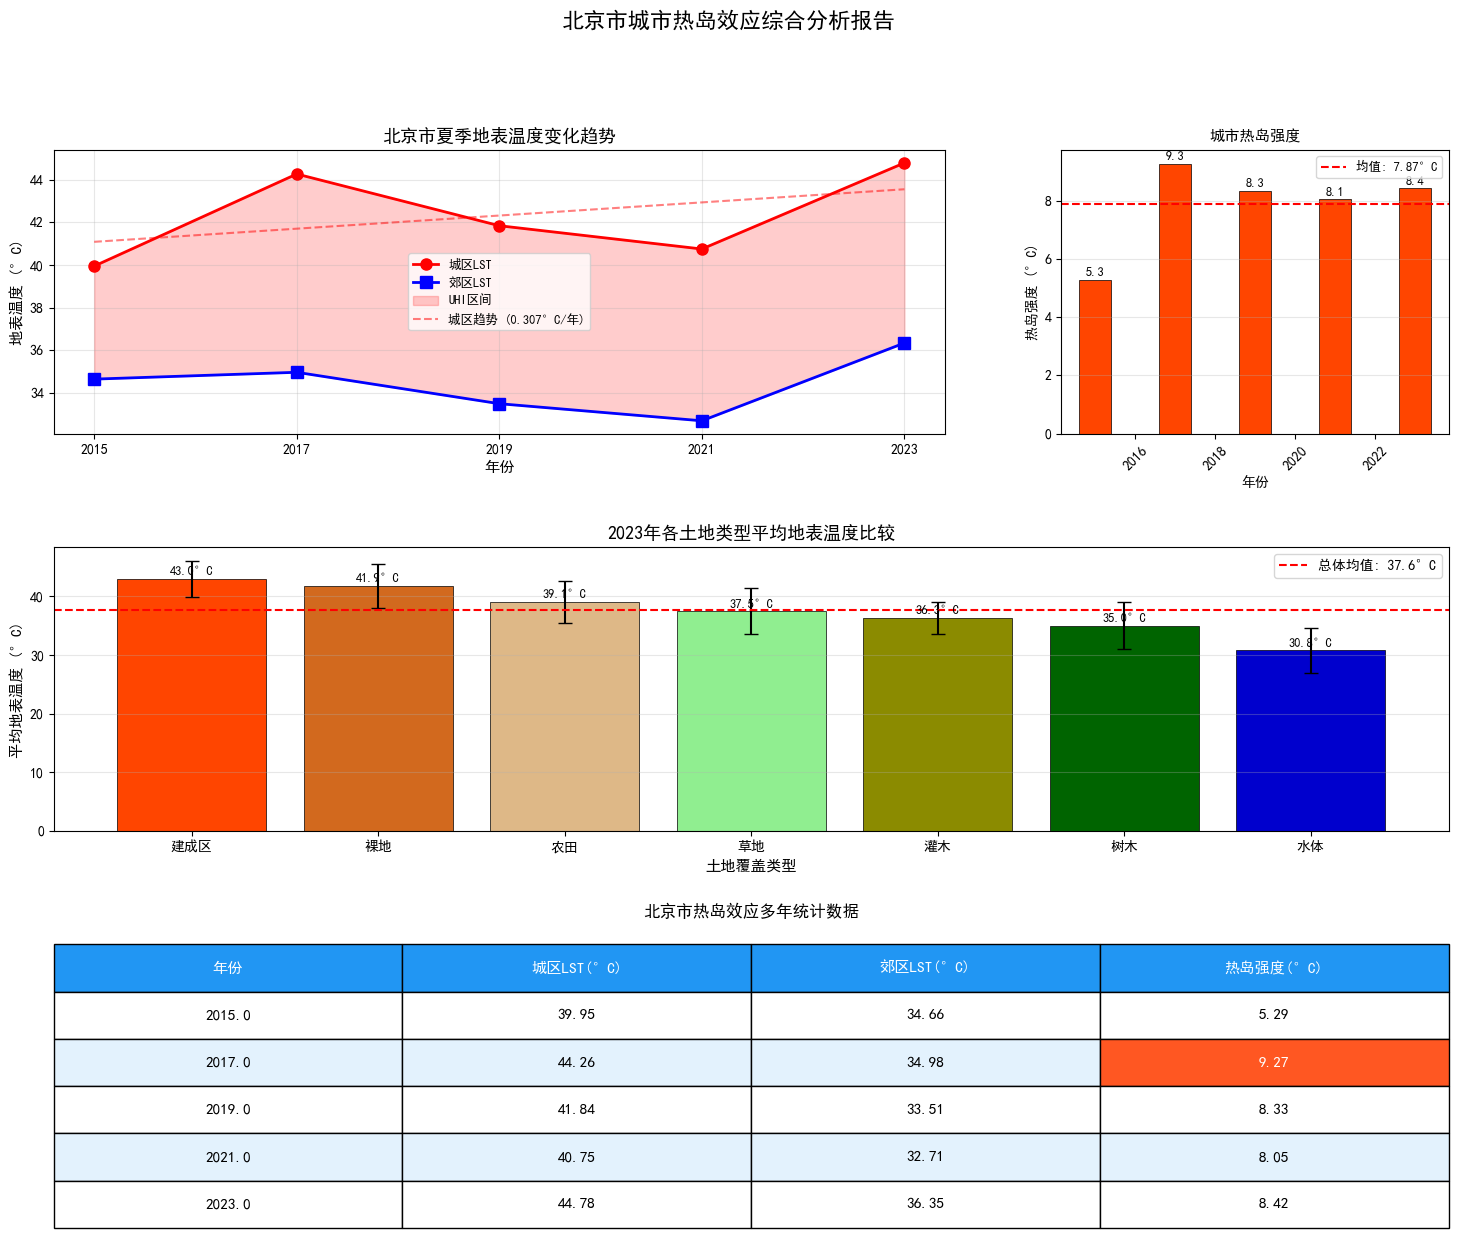

✅ 综合分析报告图已保存


In [ ]:

# ============================================
# 8.8 综合图表制作
# ============================================

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.3)

# 图1：多年LST时间趋势
ax1 = fig.add_subplot(gs[0, :2])
if len(df_uhi) > 0:
    ax1.plot(df_uhi['year'], df_uhi['urban_temp'], 'r-o', linewidth=2,
             markersize=8, label='城区LST')
    ax1.plot(df_uhi['year'], df_uhi['rural_temp'], 'b-s', linewidth=2,
             markersize=8, label='郊区LST')
    ax1.fill_between(df_uhi['year'], df_uhi['rural_temp'], df_uhi['urban_temp'],
                     alpha=0.2, color='red', label='UHI区间')

    # 添加趋势线
    if len(df_uhi) >= 3:
        z_urban = np.polyfit(df_uhi['year'], df_uhi['urban_temp'], 1)
        p_urban = np.poly1d(z_urban)
        ax1.plot(df_uhi['year'], p_urban(df_uhi['year']), 'r--',
                 alpha=0.5, label=f'城区趋势 ({z_urban[0]:.3f}°C/年)')

    ax1.set_xlabel('年份', fontsize=11)
    ax1.set_ylabel('地表温度 (°C)', fontsize=11)
    ax1.set_title('北京市夏季地表温度变化趋势', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(df_uhi['year'])

# 图2：热岛强度变化
ax2 = fig.add_subplot(gs[0, 2])
if len(df_uhi) > 0:
    colors_uhi = ['#FF4500' if v > 3 else '#FFA500' if v > 2 else '#FFD700'
                  for v in df_uhi['uhi_intensity']]
    bars = ax2.bar(df_uhi['year'], df_uhi['uhi_intensity'],
                   color=colors_uhi, edgecolor='black', linewidth=0.5)
    ax2.set_xlabel('年份', fontsize=10)
    ax2.set_ylabel('热岛强度 (°C)', fontsize=10)
    ax2.set_title('城市热岛强度', fontsize=11, fontweight='bold')
    ax2.axhline(y=df_uhi['uhi_intensity'].mean(), color='red',
                linestyle='--', label=f'均值: {df_uhi["uhi_intensity"].mean():.2f}°C')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.tick_params(axis='x', rotation=45)

    for bar, val in zip(bars, df_uhi['uhi_intensity']):
        ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9)

# 图3：土地利用与LST关系
ax3 = fig.add_subplot(gs[1, :])
if len(df_lc_lst) > 0:
    lc_colors_map = {
        '树木': '#006400', '灌木': '#8B8B00', '草地': '#90EE90',
        '农田': '#DEB887', '建成区': '#FF4500', '裸地': '#D2691E', '水体': '#0000CD'
    }
    bar_colors = [lc_colors_map.get(lc, 'gray') for lc in df_lc_lst['land_cover']]

    bars = ax3.bar(df_lc_lst['land_cover'], df_lc_lst['mean_lst'],
                   yerr=df_lc_lst['std_lst'], color=bar_colors,
                   edgecolor='black', linewidth=0.5, capsize=5)

    ax3.axhline(y=df_lc_lst['mean_lst'].mean(), color='red',
                linestyle='--', label=f'总体均值: {df_lc_lst["mean_lst"].mean():.1f}°C')
    ax3.set_xlabel('土地覆盖类型', fontsize=11)
    ax3.set_ylabel('平均地表温度 (°C)', fontsize=11)
    ax3.set_title(f'{latest_year}年各土地类型平均地表温度比较', fontsize=13, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3, axis='y')

    for bar, val in zip(bars, df_lc_lst['mean_lst']):
        ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{val:.1f}°C', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 图4：热岛效应说明与数据汇总
ax4 = fig.add_subplot(gs[2, :])
ax4.axis('off')

# 创建数据汇总表
if len(df_uhi) > 0:
    table_data = df_uhi[['year', 'urban_temp', 'rural_temp', 'uhi_intensity']].values.tolist()
    col_labels = ['年份', '城区LST(°C)', '郊区LST(°C)', '热岛强度(°C)']

    table = ax4.table(
        cellText=table_data,
        colLabels=col_labels,
        cellLoc='center',
        loc='center',
        bbox=[0, 0, 1, 1]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2)

    # 设置表格样式
    for (i, j), cell in table.get_celld().items():
        if i == 0:
            cell.set_facecolor('#2196F3')
            cell.set_text_props(color='white', fontweight='bold')
        elif i % 2 == 0:
            cell.set_facecolor('#E3F2FD')

        # 高亮最大热岛强度
        if j == 3 and i > 0:
            uhi_val = float(table_data[i-1][3])
            if uhi_val == df_uhi['uhi_intensity'].max():
                cell.set_facecolor('#FF5722')
                cell.set_text_props(color='white')

ax4.set_title('北京市热岛效应多年统计数据', fontsize=12, fontweight='bold', pad=20)

# 添加总标题
fig.suptitle('北京市城市热岛效应综合分析报告',
             fontsize=16, fontweight='bold', y=0.98)

plt.savefig('uhi_analysis_report.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✅ 综合分析报告图已保存")


In [ ]:

# ============================================
# 8.9 输出分析报告
# ============================================

print("\n" + "=" * 60)
print("          北京市城市热岛效应分析报告")
print("=" * 60)

if len(df_uhi) > 0:
    print(f"\n📊 数据概况：")
    print(f"   分析时段: {min(df_uhi['year'])} - {max(df_uhi['year'])} 年夏季")
    print(f"   数据来源: Landsat 8/9 Level-2 地表反射率产品")
    print(f"   空间分辨率: 30m")

    print(f"\n🌡️  温度分析：")
    print(f"   城区平均LST: {df_uhi['urban_temp'].mean():.2f} °C")
    print(f"   郊区平均LST: {df_uhi['rural_temp'].mean():.2f} °C")
    print(f"   平均热岛强度: {df_uhi['uhi_intensity'].mean():.2f} °C")
    print(f"   最大热岛强度: {df_uhi['uhi_intensity'].max():.2f} °C ({df_uhi.loc[df_uhi['uhi_intensity'].idxmax(), 'year']}年)")

    # 计算温度变化趋势
    if len(df_uhi) >= 3:
        trend_urban = np.polyfit(df_uhi['year'], df_uhi['urban_temp'], 1)[0]
        trend_uhi = np.polyfit(df_uhi['year'], df_uhi['uhi_intensity'], 1)[0]
        print(f"\n📈  变化趋势：")
        print(f"   城区LST变化趋势: {trend_urban:+.3f} °C/年")
        print(f"   热岛强度变化趋势: {trend_uhi:+.3f} °C/年")

if len(df_lc_lst) > 0:
    hottest = df_lc_lst.iloc[0]
    coolest = df_lc_lst.iloc[-1]
    print(f"\n🗺️  土地利用影响：")
    print(f"   最热土地类型: {hottest['land_cover']} ({hottest['mean_lst']:.2f}°C)")
    print(f"   最凉土地类型: {coolest['land_cover']} ({coolest['mean_lst']:.2f}°C)")
    print(f"   温差: {hottest['mean_lst'] - coolest['mean_lst']:.2f}°C")

print(f"\n💡  建议：")
print(f"   1. 增加城区绿地和树木覆盖，可有效降低地表温度")
print(f"   2. 推广绿色建筑和屋顶绿化")
print(f"   3. 保护和增加水体面积，利用水体降温效应")
print(f"   4. 合理规划城市通风廊道，缓解热岛效应")

print("\n" + "=" * 60)
print("📁 输出文件：")
print("   - uhi_analysis_report.png (综合分析图)")
print("   - (地图可视化见 Jupyter 输出)")
print("=" * 60)



          北京市城市热岛效应分析报告

📊 数据概况：
   分析时段: 2015 - 2023 年夏季
   数据来源: Landsat 8/9 Level-2 地表反射率产品
   空间分辨率: 30m

🌡️  温度分析：
   城区平均LST: 42.32 °C
   郊区平均LST: 34.44 °C
   平均热岛强度: 7.87 °C
   最大热岛强度: 9.27 °C (2017年)

📈  变化趋势：
   城区LST变化趋势: +0.307 °C/年
   热岛强度变化趋势: +0.252 °C/年

🗺️  土地利用影响：
   最热土地类型: 建成区 (43.01°C)
   最凉土地类型: 水体 (30.78°C)
   温差: 12.23°C

💡  建议：
   1. 增加城区绿地和树木覆盖，可有效降低地表温度
   2. 推广绿色建筑和屋顶绿化
   3. 保护和增加水体面积，利用水体降温效应
   4. 合理规划城市通风廊道，缓解热岛效应

📁 输出文件：
   - uhi_analysis_report.png (综合分析图)
   - (地图可视化见 Jupyter 输出)


In [ ]:

# ============================================
# 8.10 数据导出
# ============================================

print("\n准备数据导出...")

# 导出LST影像到 Google Drive
if latest_year in lst_dict:
    task_lst = ee.batch.Export.image.toDrive(
        image=lst_dict[latest_year],
        description=f'Beijing_LST_{latest_year}_Summer',
        folder='geemap_exports',
        fileNamePrefix=f'beijing_lst_{latest_year}',
        scale=30,
        region=beijing_roi,
        crs='EPSG:4326',
        maxPixels=1e13
    )
    # task_lst.start()
    print(f"✅ {latest_year}年LST导出任务已准备")

# 导出热岛分级到 Google Drive
task_uhi = ee.batch.Export.image.toDrive(
    image=uhi_classified,
    description=f'Beijing_UHI_Class_{latest_year}',
    folder='geemap_exports',
    fileNamePrefix=f'beijing_uhi_class_{latest_year}',
    scale=30,
    region=beijing_roi,
    crs='EPSG:4326',
    maxPixels=1e13,
    formatOptions={'cloudOptimized': True}
)
# task_uhi.start()
print("✅ 热岛分级导出任务已准备")

# 导出统计数据到CSV
if len(df_uhi) > 0:
    df_uhi.to_csv('beijing_uhi_statistics.csv', index=False, encoding='utf-8-sig')
    print("✅ 统计数据已导出到 beijing_uhi_statistics.csv")

if len(df_lc_lst) > 0:
    df_lc_lst.to_csv('beijing_lc_lst_statistics.csv', index=False, encoding='utf-8-sig')
    print("✅ 土地利用LST统计已导出到 beijing_lc_lst_statistics.csv")

print("\n✅ 综合实战项目完成！")


准备数据导出...
✅ 2023年LST导出任务已准备
✅ 热岛分级导出任务已准备
✅ 统计数据已导出到 beijing_uhi_statistics.csv
✅ 土地利用LST统计已导出到 beijing_lc_lst_statistics.csv

✅ 综合实战项目完成！


---

## 附录：常用代码片段

### A. 常用坐标系转换

In [ ]:
# ============================================
# 附录A：常用工具代码
# ============================================

import ee
import geemap

ee.Initialize(project='ee-xyt556')

# ============================================
# A.1 坐标系相关
# ============================================

# 检查影像投影
image = ee.Image('USGS/SRTMGL1_003')
projection = image.projection()
print("CRS:", projection.crs().getInfo())
print("Scale:", projection.nominalScale().getInfo(), "m")

# 重投影到 CGCS2000
image_cgcs = image.reproject(crs='EPSG:4490', scale=30)

# 重投影到 UTM zone 50N (北京地区)
image_utm = image.reproject(crs='EPSG:32650', scale=30)

# ============================================
# A.2 常用影像集合
# ============================================

catalog = {
    "Landsat 8 TOA": "LANDSAT/LC08/C02/T1_TOA",
    "Landsat 8 SR": "LANDSAT/LC08/C02/T1_L2",
    "Landsat 9 TOA": "LANDSAT/LC09/C02/T1_TOA",
    "Sentinel-2 SR": "COPERNICUS/S2_SR_HARMONIZED",
    "MODIS NDVI": "MODIS/006/MOD13Q1",
    "MODIS 地表温度": "MODIS/006/MOD11A1",
    "SRTM DEM": "USGS/SRTMGL1_003",
    "ALOS DEM": "JAXA/ALOS/AW3D30/V3_2",
    "ESA WorldCover": "ESA/WorldCover/v200",
    "夜间灯光(VIIRS)": "NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG",
    "GPM降水": "NASA/GPM_L3/IMERG_V06",
    "ERA5气候": "ECMWF/ERA5/MONTHLY"
}

print("常用GEE数据集：")
for name, id in catalog.items():
    print(f"  {name}: {id}")

# ============================================
# A.3 批量处理模板
# ============================================

def batch_process(region, years, func):
    """批量处理多年数据"""
    results = {}
    for year in years:
        print(f"处理 {year} 年...")
        try:
            result = func(year, region)
            results[year] = result
            print(f"  ✅ {year} 年完成")
        except Exception as e:
            print(f"  ❌ {year} 年出错: {e}")
    return results

# 使用示例
def get_annual_ndvi(year, region):
    return (ee.ImageCollection('MODIS/006/MOD13Q1')
            .filterDate(f'{year}-01-01', f'{year}-12-31')
            .select('NDVI')
            .mean()
            .multiply(0.0001)
            .clip(region))

test_region = ee.Geometry.Rectangle([116.0, 39.5, 117.0, 40.5])
# results = batch_process(test_region, [2018, 2019, 2020, 2021, 2022], get_annual_ndvi)

# ============================================
# A.4 结果导出模板
# ============================================

def export_to_drive(image, name, region, scale=30, folder='GEE_Exports'):
    """导出影像到Google Drive"""
    task = ee.batch.Export.image.toDrive(
        image=image,
        description=name,
        folder=folder,
        fileNamePrefix=name,
        scale=scale,
        region=region,
        crs='EPSG:4326',
        maxPixels=1e13,
        formatOptions={'cloudOptimized': True}
    )
    task.start()
    print(f"✅ 导出任务 '{name}' 已提交")
    print(f"   在 Google Drive 的 '{folder}' 文件夹中查看")
    return task

def export_fc_to_drive(fc, name, folder='GEE_Exports'):
    """导出矢量数据到Google Drive"""
    task = ee.batch.Export.table.toDrive(
        collection=fc,
        description=name,
        folder=folder,
        fileNamePrefix=name,
        fileFormat='SHP'  # 或 'CSV', 'GeoJSON', 'KML'
    )
    task.start()
    print(f"✅ 矢量导出任务 '{name}' 已提交")
    return task

# ============================================
# A.5 常用可视化参数模板
# ============================================

vis_params_library = {
    "真彩色(Landsat8)": {
        'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3, 'gamma': 1.4
    },
    "假彩色(植被,Landsat8)": {
        'bands': ['B5', 'B4', 'B3'], 'min': 0, 'max': 0.5, 'gamma': 1.3
    },
    "真彩色(Sentinel2)": {
        'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000, 'gamma': 1.3
    },
    "NDVI": {
        'min': -0.2, 'max': 0.8,
        'palette': ['#d73027', '#f7f7f7', '#1a9850']
    },
    "高程(SRTM)": {
        'min': 0, 'max': 5000,
        'palette': ['006633', 'E5FFCC', '662A00', 'D8D8D8', 'F5F5F5']
    },
    "地表温度(LST)": {
        'min': 15, 'max': 55,
        'palette': ['040274', '040281', '0502a3', '0502b8', '0602ff',
                    '235cb1', '307ef3', '269db1', '30c8e2', '32d3ef',
                    '3be285', '3ff38f', '86e26f', '3ae237', 'b5e22e',
                    'd6e21f', 'fff705', 'ffd611', 'ffb613', 'ff8b13',
                    'ff6e08', 'ff500d', 'ff0000', 'de0101', 'c21301']
    },
    "夜间灯光": {
        'min': 0, 'max': 200,
        'palette': ['000000', '0d0d0d', '1a1a1a', 'ffff00', 'ffffff']
    }
}

print("可视化参数库已加载，包含以下预设：")
for name in vis_params_library.keys():
    print(f"  - {name}")

---

## 课程总结与评估

### 知识点总结

| 章节 | 主要知识点 | 核心技能 |
|------|----------|---------|
| 第1章 | 环境配置、基础地图 | geemap.Map(), add_basemap() |
| 第2章 | 影像加载、可视化 | addLayer(), 可视化参数 |
| 第3章 | 影像集合处理 | filter(), map(), reduce() |
| 第4章 | 植被分析、土地利用 | 指数计算, WorldCover |
| 第5章 | 矢量数据处理 | FeatureCollection, 区域统计 |
| 第6章 | 变化检测、专题图 | 差值法, 分级, 导出 |
| 第7章 | DEM地形分析 | Terrain, 坡度坡向 |
| 第8章 | 综合实战 | LST反演, 热岛分析 |

### 学习评估

In [ ]:
# ============================================
# 课程作业评估代码模板
# ============================================

"""
作业题目：选择一个感兴趣的城市，完成以下分析：

1. 基础要求（60分）：
   - 加载并显示该城市的Sentinel-2或Landsat影像
   - 计算NDVI并可视化
   - 加载土地利用数据并进行面积统计

2. 进阶要求（30分）：
   - 进行多年NDVI时间序列分析
   - 检测过去5年内的土地利用变化
   - 绘制完整的统计图表

3. 创新要求（10分）：
   - 结合其他数据源（DEM、降雨、夜间灯光等）
   - 提出有价值的空间分析问题并解答
   - 输出完整的分析报告

提交内容：
- Jupyter Notebook (.ipynb)
- 输出图表 (.png)
- 分析报告 (.pdf 或 .docx)
"""

# 评估标准
grading_criteria = {
    "代码规范性": 10,
    "数据处理正确性": 20,
    "可视化质量": 20,
    "分析深度": 30,
    "报告完整性": 20
}

print("评估标准：")
for criterion, score in grading_criteria.items():
    print(f"  {criterion}: {score}分")
print(f"  总分: {sum(grading_criteria.values())}分")

---

## 参考资源

```markdown
📚 学习资源：

1. 官方文档：
   - Geemap 文档: https://geemap.org
   - GEE Python API: https://developers.google.com/earth-engine/guides
   - GEE 数据目录: https://developers.google.com/earth-engine/datasets

2. 学习教程：
   - Geemap GitHub: https://github.com/gee-community/geemap
   - GEE 社区教程: https://developers.google.com/earth-engine/tutorials
   - Open Geospatial Solutions: https://www.youtube.com/@giswqs

3. 数据资源：
   - 全球30m DEM: SRTM, ALOS
   - 土地利用: ESA WorldCover, MODIS LC
   - 气候数据: ERA5, GPM
   - 夜间灯光: VIIRS, DMSP

4. 推荐书籍：
   - 《Google Earth Engine 云地理计算》
   - 《Python 地理空间分析》
   - 《遥感数字图像处理》
```

---

> **注意事项：**
> 1. 使用前需要注册 Google Earth Engine 账号并获取项目ID
> 2. 首次使用需要运行 `ee.Authenticate()` 进行认证
> 3. 大数据量计算可能较慢，建议使用 `bestEffort=True` 参数
> 4. 导出任务请在 GEE Tasks 页面查看进度
> 5. 所有 `ee-xyt556` 需替换为实际项目ID